# Z4 PHYSICAL (non-PRS) 5-seed statistical $\beta_4$ scan --- analysis

Scan directory `scan_z4_phys_stat/`: **physical EOM (`prsWall = false`)**, $\mu=0.07$,
$N=512$, **per-$\beta$ box** (each run sized so it ends at exactly 2 comoving horizons per
side), $\beta_4\in\{0.1,0.3,0.5,0.7,0.9\}$, **5 seeds per $\beta_4$** (25 runs). Seeds are
**paired** (common random numbers) with the PRS stat scan `scan_z4_prs_stat/`, so each run
is the same IC realization as its PRS twin.

**Why this scan exists:** the PRS method appears *not* to scale, while single-realization
*physical* runs look like they do --- but a single seed cannot beat cosmic (sample)
variance. This is the statistical **physical twin** of the PRS scan (same $\beta_4$ grid,
identical couplings, PRS turned off) to settle whether the *physical* wall network reaches
scaling.

**RAW units --- $\mu\neq 1$ rescales the radial markers (this is the key difference from the
PRS notebooks):** `average_scalar` is in raw field units, so the broken vacuum sits at
$\langle|\Phi|^2\rangle = v^2/2 = \mu^2/2 = 0.00245$ **(not 0.5)** and the breaking marker
is $\mu^2/4 = 0.001225$ **(not 0.25)**. Formation is **late** ($a_{\rm form}\sim16$--$22$)
because the tachyonic drive $\propto\mu^2$; with $H_0/\mu=1$ the background is
$a = 1+\eta$.

**Per-$\beta$ box (variable $L$).** Unlike the PRS scan (one shared box), each $\beta$ here
has its own $L$, sized by `gen_phys_stat_cards.py`:
$a_{\max}=\sqrt{\bar\delta\,N/(\mu\,n_{\rm res}\,h_{\rm min})}$, $L=h_{\rm min}a_{\max}$,
$n_{\rm res}=1$, $h_{\rm min}=2$ --- so **every run ends at exactly 2 horizons/side**, and
the thinnest wall is still $\geq 1$ cell at the end. The wall starts very fat
($\propto1/\mu$ in cells) and thins $\propto1/a$.

**Scaling convention (do not use raw `scal`):**
$$\mathcal{A}_1 \equiv \frac{\mathrm{scal}_1}{2aH}\ \ (\text{adjacent walls}), \qquad
  \mathcal{A}_2 \equiv \frac{\mathrm{scal}_2}{2aH}\ \ (\text{opposite walls}),$$
with $a,H$ read from `average_scale_factor.txt` (columns `[eta, a, a', H]` --- we use
**column 1 ($a$) and column 3 ($H$)**, not column 2 ($a'$)). `average_energies.txt` has
**11 columns**: `[eta, Ek1, Ek2, Eg1, Eg2, Ev1, Ev2, Ev3, Etot, scal1, scal2]`, i.e.
`scal1` = column 9 (adjacent) and `scal2` = column 10 (opposite).

**Cross-$\beta$ comparison = equal-horizon / own-end.** Because the boxes differ, $\S 8$
(in-window slope) and $\S 9$ (plateau) measure each $\beta$ at its **own** late time (its
2-horizon end), i.e. at matched horizon coverage --- not at a shared $\eta$.

In [2]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# Set True for the paper LaTeX style (requires a local LaTeX install); False lets this
# notebook execute anywhere (e.g. CI / headless nodes without latex).
USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

In [3]:
BASE = '/mt/user-batch/dpasari/scan_z4_phys_stat/'

MU      = 0.07
N       = 512
N_SEEDS = 5
N_RES   = 1.0      # cells/wall required at a_max (box-sizing target)
H_MIN   = 2.0      # horizons/side required at a_max

BETAS = [0.1, 0.3, 0.5, 0.7, 0.9]
BLAB  = {0.1: '1', 0.3: '3', 0.5: '5', 0.7: '7', 0.9: '9'}


# RAW-units radial markers (mu != 1): vacuum <|Phi|^2> = mu^2/2, breaking marker = mu^2/4
VAC   = MU**2 / 2.0     # 0.002450
BREAK = MU**2 / 4.0     # 0.001225

# dimensionless BVP wall widths (delta_bar). Z4 thinnest wall = min(adjacent, opposite=1.40).
D_ADJ = {0.1: 2.38, 0.3: 1.46, 0.5: 1.22, 0.7: 1.113, 0.9: 1.087}
D_OPP = 1.40
def _dmin(b):
    return min(D_ADJ[b], D_OPP)

# Per-beta box (same sizer as gen_phys_stat_cards.py). a = 1+eta (H0/mu = 1).
def _amax(b):
    return math.sqrt(_dmin(b) * N / (MU * N_RES * H_MIN))
A_MAX = {b: _amax(b)        for b in BETAS}
L     = {b: H_MIN * A_MAX[b] for b in BETAS}
DX    = {b: L[b] / N         for b in BETAS}
TMAX  = {b: A_MAX[b] - 1.0   for b in BETAS}

_CMAP = plt.cm.winter
COLOR = {b: _CMAP((b - 0.1) / 0.8) for b in BETAS}
LABEL = {b: rf'$\beta_4={b}$' for b in BETAS}

def config_handles(betas):
    return [Line2D([0], [0], color=COLOR[b], lw=2.4, ls='solid', label=LABEL[b])
            for b in betas]

def add_legend(ax, betas, **kw):
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=config_handles(betas), **kw)

def run_dir(beta, seed):
    return os.path.join(BASE, f'results_DWZ4_physstat_b40p{BLAB[beta]}_s{seed:02d}')

# Sizing sanity table: cells/wall (start a=1 vs end a=a_max) and the per-beta box.
print(f"{'beta4':>6s} {'L':>8s} {'dx':>7s} {'a_max':>7s} {'adj@1':>8s}"
      f" {'adj@end':>8s} {'opp@end':>8s} {'hor@end':>8s}")
print('-' * 64)
for b in BETAS:
    adj_start = D_ADJ[b] / (MU * 1.0 * DX[b])
    adj_end   = D_ADJ[b] / (MU * A_MAX[b] * DX[b])
    opp_end   = D_OPP    / (MU * A_MAX[b] * DX[b])
    print(f"{b:>6.1f} {L[b]:>8.1f} {DX[b]:>7.3f} {A_MAX[b]:>7.1f} {adj_start:>8.1f}"
          f" {adj_end:>8.2f} {opp_end:>8.2f} {H_MIN:>8.1f}")

 beta4        L      dx   a_max    adj@1  adj@end  opp@end  hor@end
----------------------------------------------------------------
   0.1    143.1   0.280    71.6    121.6     1.70     1.00      2.0
   0.3    143.1   0.280    71.6     74.6     1.04     1.00      2.0
   0.5    133.6   0.261    66.8     66.8     1.00     1.15      2.0
   0.7    127.6   0.249    63.8     63.8     1.00     1.26      2.0
   0.9    126.1   0.246    63.1     63.1     1.00     1.29      2.0


## Loaders

Per-(`beta`,`seed`) loader returns the data products or `None` if any file is
missing/empty/too-short (`plot-if-ran`: missing seeds are silently skipped downstream).

In [4]:
def load_energies(path):
    # Z4: 11 cols -- eta,Ek1,Ek2,Eg1,Eg2,Ev1,Ev2,Ev3,Etot,scal1(adj),scal2(opp)
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 11:
        return None
    return {
        'eta':   data[:, 0], 'Ek_1': data[:, 1], 'Ek_2': data[:, 2],
        'Eg_1':  data[:, 3], 'Eg_2': data[:, 4], 'Ev_1': data[:, 5],
        'Ev_2':  data[:, 6], 'Ev_3': data[:, 7], 'E_tot': data[:, 8],
        'scal1': data[:, 9], 'scal2': data[:, 10],
    }


def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_scalar(path, idx):
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta': data[:, 0], 'phi': data[:, 1], 'phi_prime': data[:, 2],
        'phi2': data[:, 3], 'phi_prime2': data[:, 4], 'rms_phi': data[:, 5],
    }


def load_scale_factor(path):
    # Cols: eta, a, a', H -- use a=col1, H=col3 (NOT a'=col2)
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:, 0], 'a': data[:, 1], 'aprime': data[:, 2], 'H': data[:, 3]}


def load_run(beta, seed):
    path = run_dir(beta, seed)
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    if any(x is None for x in [en, sf, s0, s1]):
        return None
    if len(en['eta']) < 2 or len(sf['eta']) < 2:
        return None
    return {'beta': beta, 'seed': seed, 'energies': en, 'scale_factor': sf,
            'scalar_0': s0, 'scalar_1': s1}

## Load all runs

Discovery: how many of the 5 seeds are present per $\beta$, and how far each ran (the
planned end is each $\beta$'s 2-horizon $\eta$).

In [5]:
# Discovery: how many of the 5 seeds are present per beta, and their last eta.
RUNS = {}
print(f"{'beta':>6s} {'n_seeds':>8s} {'last_eta (per seed)'}")
print('-' * 90)
for b in BETAS:
    runs = {}
    last_etas = []
    for s in range(1, N_SEEDS + 1):
        r = load_run(b, s)
        if r is not None:
            runs[s] = r
            last_etas.append(r['energies']['eta'][-1])
    RUNS[b] = runs
    last_str = ', '.join(f'{x:.1f}' for x in last_etas)
    print(f"{b:>6.1f} {len(runs):>8d}   [{last_str}]  (planned end {TMAX[b]:.1f})")

  beta  n_seeds last_eta (per seed)
------------------------------------------------------------------------------------------
   0.1        5   [70.5, 70.5, 70.5, 70.5, 70.5]  (planned end 70.6)
   0.3        5   [70.5, 70.5, 70.5, 70.5, 70.5]  (planned end 70.6)
   0.5        5   [65.7, 65.7, 65.7, 65.7, 65.7]  (planned end 65.8)
   0.7        5   [62.7, 62.7, 62.7, 62.7, 62.7]  (planned end 62.8)
   0.9        5   [62.0, 62.0, 62.0, 62.0, 62.0]  (planned end 62.1)


## Plot helpers

In [6]:
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel: ax.set_ylabel(ylabel, fontsize=24)
    if title:  ax.set_title(title,   fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def phi2_radial(run):
    # <|Phi|^2> = (phi2 of field 0 + phi2 of field 1) / 2; RAW units (vacuum = mu^2/2)
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    return s0['eta'][:n], (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0


def breaking_onset_eta(run):
    # FORMATION onset = the turnaround (minimum) of <|Phi|^2>. The raw initial fluctuations
    # are NOT mu^2-scaled (p2 starts ~0.1 >> vacuum mu^2/2), decay ~1/a^2 to a minimum near
    # a ~ 14-16, then the tachyonic instability grows p2 back up to the broken vacuum mu^2/2.
    # A plain threshold crossing fails (p2 starts far above mu^2/4), so use the interior min.
    eta, p2 = phi2_radial(run)
    if eta.size < 5:
        return None
    i = int(np.argmin(p2))
    if i == 0 or i >= len(p2) - 1:   # no interior turnaround yet -> not formed
        return None
    return float(eta[i])


def local_logslope(x, y, nbin=60):
    # d ln y / d ln x on coarse log-spaced bins (noise-robust)
    m = (x > 0) & (y > 0) & np.isfinite(y)
    if m.sum() < 10:
        return np.array([]), np.array([])
    lx, ly = np.log(x[m]), np.log(y[m])
    edges = np.linspace(lx[0], lx[-1], nbin + 1)
    idx = np.digitize(lx, edges)
    bx, by = [], []
    for i in range(1, nbin + 1):
        sel = idx == i
        if sel.sum() > 0:
            bx.append(lx[sel].mean()); by.append(ly[sel].mean())
    bx, by = np.array(bx), np.array(by)
    if len(bx) < 4:
        return np.array([]), np.array([])
    return np.exp(0.5*(bx[1:] + bx[:-1])), np.diff(by)/np.diff(bx)


def horizon_guide_end(ax, beta):
    # each run ENDS at exactly H_MIN horizons/side; mark that eta (per beta) faintly
    eta_end = L[beta] / H_MIN - 1.0
    ax.axvline(eta_end, color=COLOR[beta], ls=':', lw=0.9, alpha=0.35)


def area_param(en_key, run):
    # A = scal / (2 a H) vs eta; a,H interpolated from the scale-factor file
    en, sf = run['energies'], run['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en[en_key] / (2.0 * a_arr * H_arr)
    return en['eta'], A

## Seed-aggregation helper

`seed_mean_std(beta, quantity_fn)`: for each available seed compute
`quantity_fn(run) -> (eta, y)`, interpolate every seed onto a common $\eta$ grid, and
return the across-seed mean and std (NaN-tolerant of partial coverage).

In [7]:
def seed_mean_std(beta, quantity_fn, n_grid=400):
    runs = RUNS.get(beta, {})
    curves = []
    eta_lo, eta_hi = None, None
    for s, run in runs.items():
        try:
            eta, y = quantity_fn(run)
        except Exception:
            continue
        eta = np.asarray(eta); y = np.asarray(y)
        if eta.size < 2:
            continue
        curves.append((eta, y))
        lo, hi = eta[0], eta[-1]
        eta_lo = lo if eta_lo is None else min(eta_lo, lo)
        eta_hi = hi if eta_hi is None else max(eta_hi, hi)
    if not curves or eta_lo is None or eta_hi <= eta_lo:
        return np.array([]), np.array([]), np.array([]), 0

    eta_grid = np.linspace(eta_lo, eta_hi, n_grid)
    stacked = np.full((len(curves), n_grid), np.nan)
    for i, (eta, y) in enumerate(curves):
        # only interpolate within this seed's own eta-range; outside -> NaN
        in_range = (eta_grid >= eta[0]) & (eta_grid <= eta[-1])
        stacked[i, in_range] = np.interp(eta_grid[in_range], eta, y)

    mean = np.nanmean(stacked, axis=0)
    std  = np.nanstd(stacked, axis=0)
    return eta_grid, mean, std, len(curves)

## 1. Health: radial diagnostic $\langle|\Phi|^2\rangle$ and mean-field drift

**Left (log-$y$):** $\langle|\Phi|^2\rangle=(\langle h^2\rangle+\langle a^2\rangle)/2$. The
raw initial fluctuations start far above the vacuum ($\sim0.1\gg\mu^2/2$), decay
$\sim1/a^2$ to a **minimum near $a\sim14$--$16$ --- the formation onset (turnaround)** ---
then the tachyonic instability ($\propto\mu^2$) grows them back up to the broken vacuum
$\mu^2/2$ (solid guide; dashed $=\mu^2/4$). Use the turnaround, *not* $E_{V_1}<0$.

**Right:** $|\langle\Phi\rangle|=\sqrt{\langle h\rangle^2+\langle a\rangle^2}$; growth
toward $\mathcal{O}(\mu)$ (faint guide) signals finite-volume domain depletion.

Each curve is the across-seed mean; the shaded band is $\pm1\sigma$ across seeds.

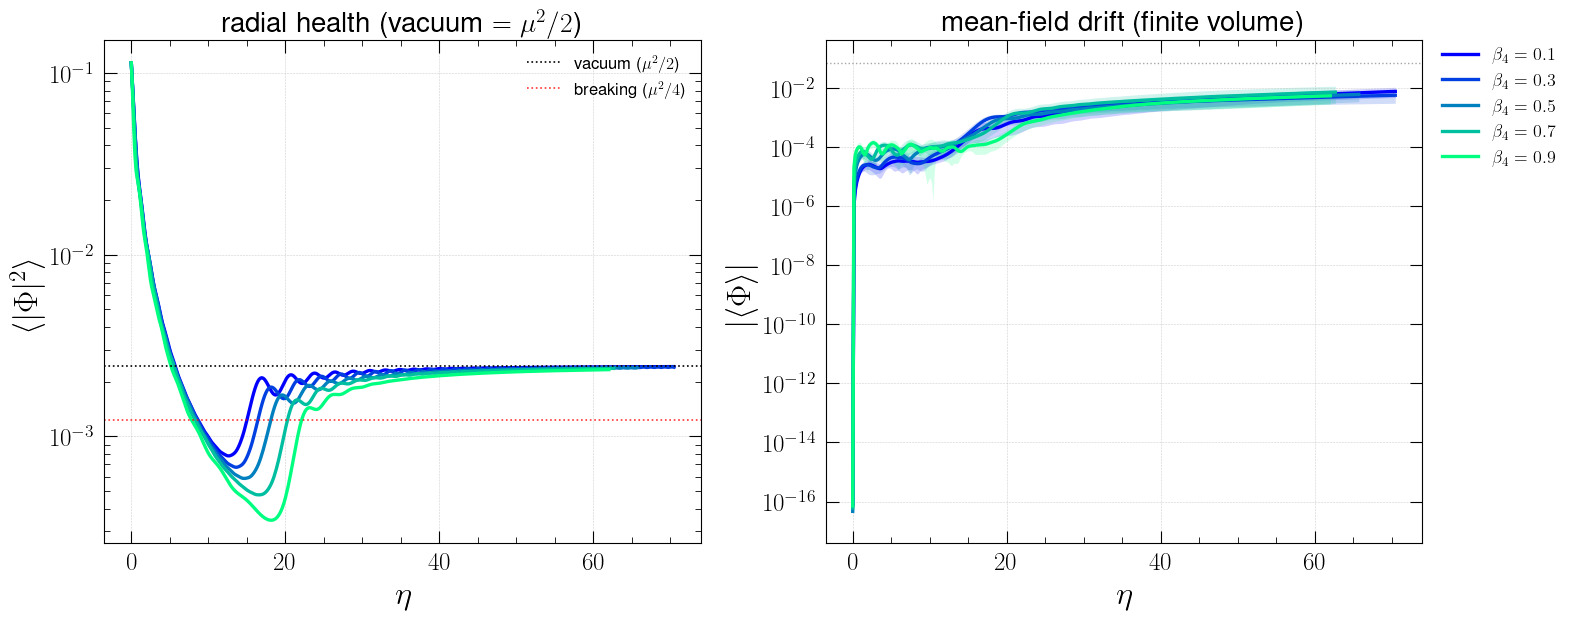

In [8]:
def drift_curve(run):
    # |<Phi>| = sqrt(<h>^2 + <a>^2); field 1 interpolated onto field 0's eta (-> O(mu) on depletion)
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    eta = s0['eta'][:n]
    phi1 = np.interp(eta, s1['eta'], s1['phi'])
    return eta, np.sqrt(s0['phi'][:n]**2 + phi1**2)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, phi2_radial)
    if eta.size:
        axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)
    etad, meand, stdd, nd = seed_mean_std(b, drift_curve)
    if etad.size:
        axes[1].plot(etad, meand, color=COLOR[b], lw=2.4)
        axes[1].fill_between(etad, meand - stdd, meand + stdd, color=COLOR[b], alpha=0.18, lw=0)

axes[0].axhline(VAC,   color='k', ls=':', lw=1.2, label=r'vacuum ($\mu^2/2$)')
axes[0].axhline(BREAK, color='r', ls=':', lw=1.2, alpha=0.8, label=r'breaking ($\mu^2/4$)')
axes[0].legend(fontsize=12, frameon=False)
axes[0].set_yscale('log')   # initial fluct (~0.1) dwarf the vacuum (mu^2/2); log shows the dip-and-rise
axes[1].axhline(MU, color='gray', ls=':', lw=1.0, alpha=0.7)
axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$\langle|\Phi|^2\rangle$',
         title=r'radial health (vacuum $=\mu^2/2$)')
paper_ax(axes[1], ylabel=r'$|\langle\Phi\rangle|$',
         title=r'mean-field drift (finite volume)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 2. Potential energies $E_{V_1}$, $E_{V_2}$, $E_{V_3}$

$E_{V_1}=-\mu^2\langle|\Phi|^2\rangle + V_0$ with a $\beta$-dependent vacuum offset $V_0$,
so $E_{V_1}$ can stay positive even in the broken vacuum. Use the
$\langle|\Phi|^2\rangle>\mu^2/4$ marker for breaking, **not** the sign of $E_{V_1}$. Right
panel: quartic terms (solid $E_{V_2}$, dashed $E_{V_3}$). Bands are seed $\pm1\sigma$.

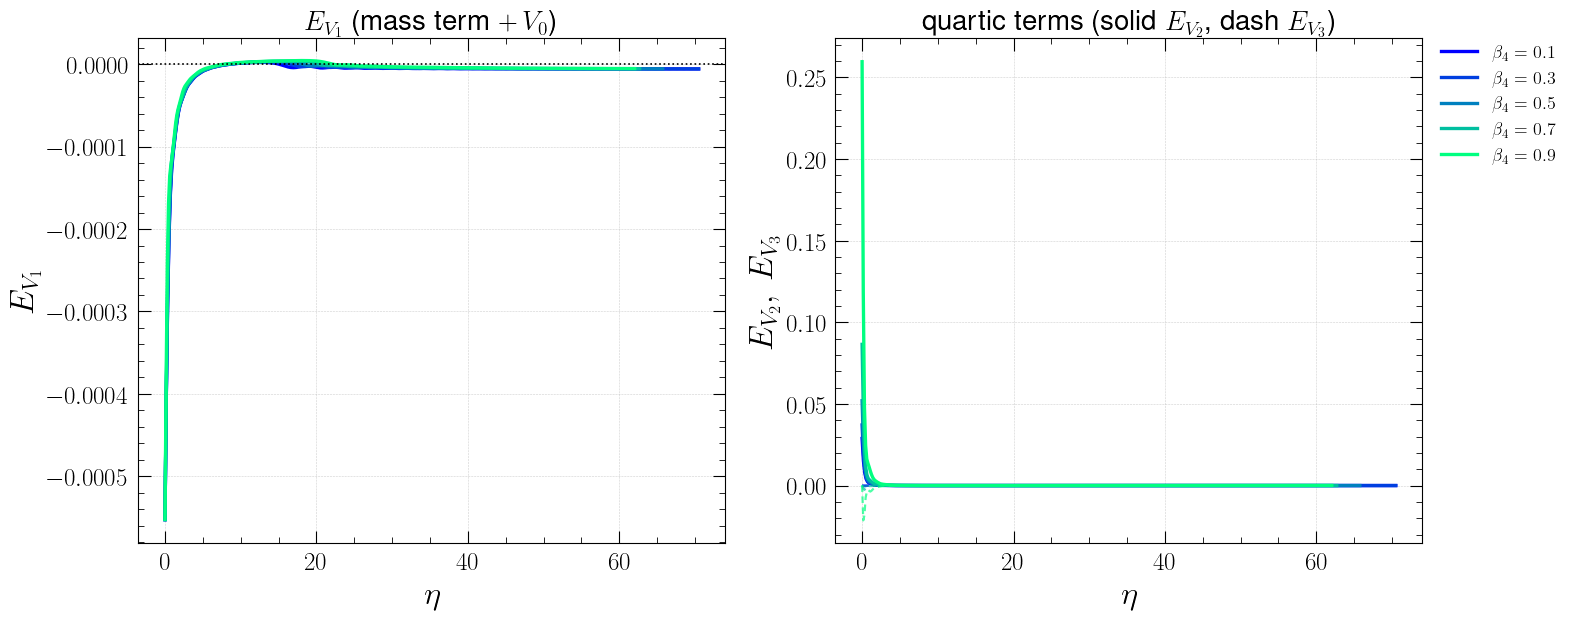

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    e1, m1, s1, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_1']))
    if e1.size:
        axes[0].plot(e1, m1, color=COLOR[b], lw=2.4)
        axes[0].fill_between(e1, m1 - s1, m1 + s1, color=COLOR[b], alpha=0.18, lw=0)
    e2, m2, s2, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_2']))
    if e2.size:
        axes[1].plot(e2, m2, color=COLOR[b], lw=2.4)
        axes[1].fill_between(e2, m2 - s2, m2 + s2, color=COLOR[b], alpha=0.18, lw=0)
    e3, m3, s3, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_3']))
    if e3.size:
        axes[1].plot(e3, m3, color=COLOR[b], ls=(0, (3, 2)), lw=1.6, alpha=0.7)

axes[0].axhline(0, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$E_{V_1}$', title=r'$E_{V_1}$ (mass term $+\,V_0$)')
paper_ax(axes[1], ylabel=r'$E_{V_2},\;E_{V_3}$',
         title=r'quartic terms (solid $E_{V_2}$, dash $E_{V_3}$)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 3. Kinetic and gradient energies

Both scalar components summed; log--log. Seed mean $\pm1\sigma$ band per $\beta$.

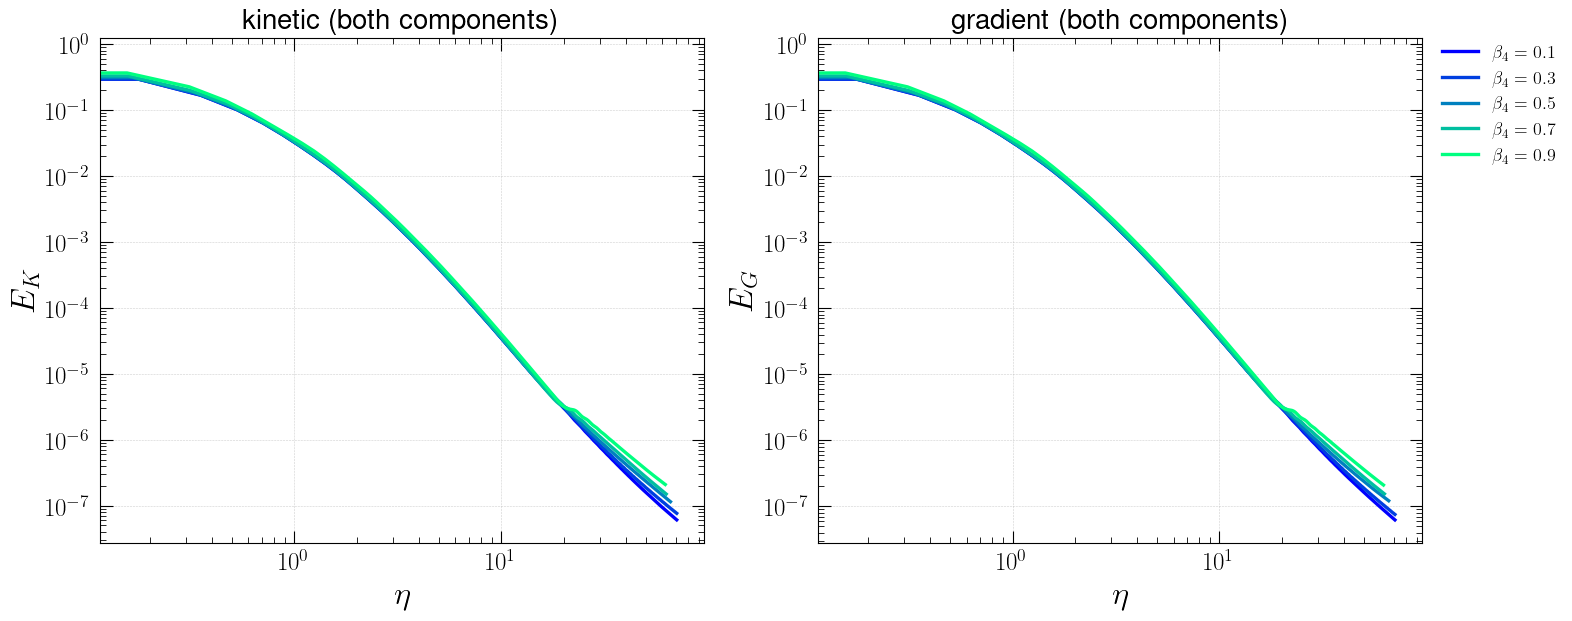

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    ek, mk, sk, _ = seed_mean_std(
        b, lambda r: (r['energies']['eta'], r['energies']['Ek_1'] + r['energies']['Ek_2']))
    if ek.size:
        axes[0].plot(ek, mk, color=COLOR[b], lw=2.4)
        axes[0].fill_between(ek, np.clip(mk - sk, 1e-30, None), mk + sk,
                             color=COLOR[b], alpha=0.18, lw=0)
    eg, mg, sg, _ = seed_mean_std(
        b, lambda r: (r['energies']['eta'], r['energies']['Eg_1'] + r['energies']['Eg_2']))
    if eg.size:
        axes[1].plot(eg, mg, color=COLOR[b], lw=2.4)
        axes[1].fill_between(eg, np.clip(mg - sg, 1e-30, None), mg + sg,
                             color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
paper_ax(axes[0], ylabel=r'$E_K$', title=r'kinetic (both components)')
paper_ax(axes[1], ylabel=r'$E_G$', title=r'gradient (both components)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 4. Scalar-field means $\langle h\rangle$, $\langle a\rangle$

Per-component volume-averaged field. The band is **seed scatter** ($\pm1\sigma$ across
seeds): each seed's mean field drifts to a random sign under finite-volume depletion, so
the seed mean sits near $0$ with a band that widens as domains deplete.

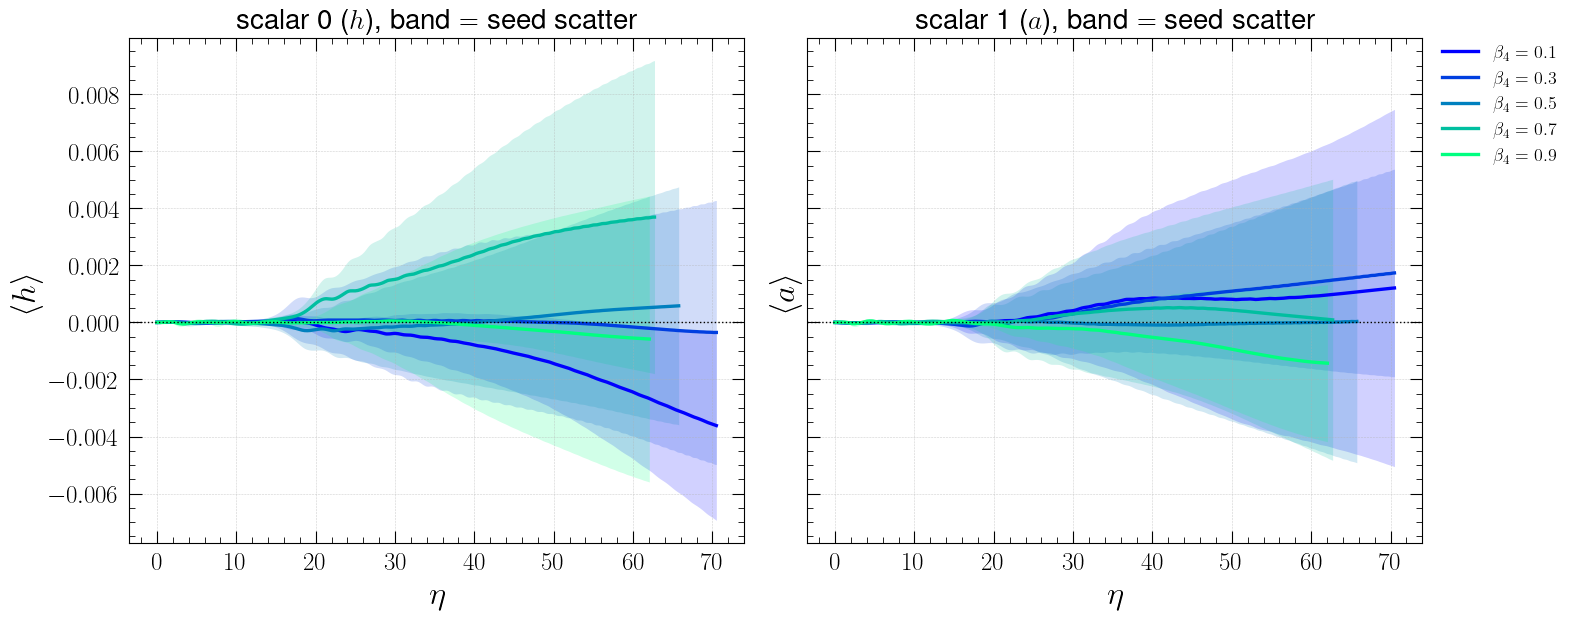

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
for b in BETAS:
    eh, mh, sh, _ = seed_mean_std(b, lambda r: (r['scalar_0']['eta'], r['scalar_0']['phi']))
    if eh.size:
        axes[0].plot(eh, mh, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eh, mh - sh, mh + sh, color=COLOR[b], alpha=0.18, lw=0)
    ea, ma, sa, _ = seed_mean_std(b, lambda r: (r['scalar_1']['eta'], r['scalar_1']['phi']))
    if ea.size:
        axes[1].plot(ea, ma, color=COLOR[b], lw=2.4)
        axes[1].fill_between(ea, ma - sa, ma + sa, color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    ax.axhline(0, color='k', ls=':', lw=1.0)
paper_ax(axes[0], ylabel=r'$\langle h\rangle$', title=r'scalar 0 ($h$), band $=$ seed scatter')
paper_ax(axes[1], ylabel=r'$\langle a\rangle$', title=r'scalar 1 ($a$), band $=$ seed scatter')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 5. Scale factor and Hubble

Sanity panel: $a(\eta)$ and the conformal Hubble $\mathcal{H}=a'/a$ from
`average_scale_factor.txt`. This is the **fixed radiation background** ($H_0=\mu$),
identical for every $\beta$ and seed: $a$ rises linearly ($a\approx1+\eta$),
$\mathcal{H}\propto1/a$, and $2aH=2a'$ is nearly constant --- so $\mathcal{A}\equiv
\mathrm{scal}/(2aH)$ divides it out exactly. (Read from file rather than assumed.)

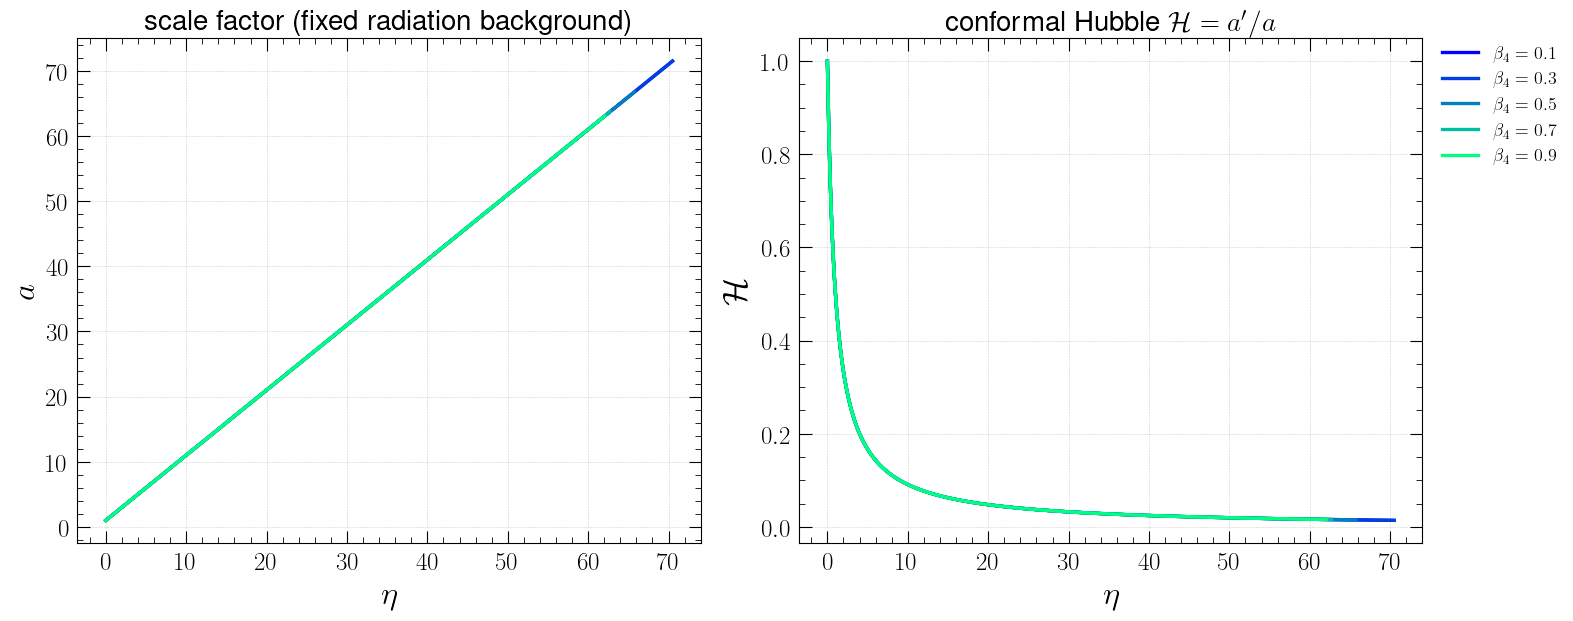

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    ea, ma, sa, _ = seed_mean_std(b, lambda r: (r['scale_factor']['eta'], r['scale_factor']['a']))
    if ea.size:
        axes[0].plot(ea, ma, color=COLOR[b], lw=2.4)
    eh, mh, sh, _ = seed_mean_std(b, lambda r: (r['scale_factor']['eta'], r['scale_factor']['H']))
    if eh.size:
        axes[1].plot(eh, mh, color=COLOR[b], lw=2.4)

paper_ax(axes[0], ylabel=r'$a$', title=r'scale factor (fixed radiation background)')
paper_ax(axes[1], ylabel=r"$\mathcal{H}$", title=r"conformal Hubble $\mathcal{H}=a'/a$")
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 6. Wall-area parameters $\mathcal{A}_1$ (adjacent) and $\mathcal{A}_2$ (opposite)

$\mathcal{A}_1\equiv\mathrm{scal}_1/(2aH)$ (adjacent), $\mathcal{A}_2\equiv
\mathrm{scal}_2/(2aH)$ (opposite); log--log, seed mean $\pm1\sigma$. The right endpoint of
each curve is that $\beta$'s **2-horizon end** (faint vertical, same colour). A plateau at
$\mathcal{A}\sim\mathcal{O}(1)$ is the scaling signature.

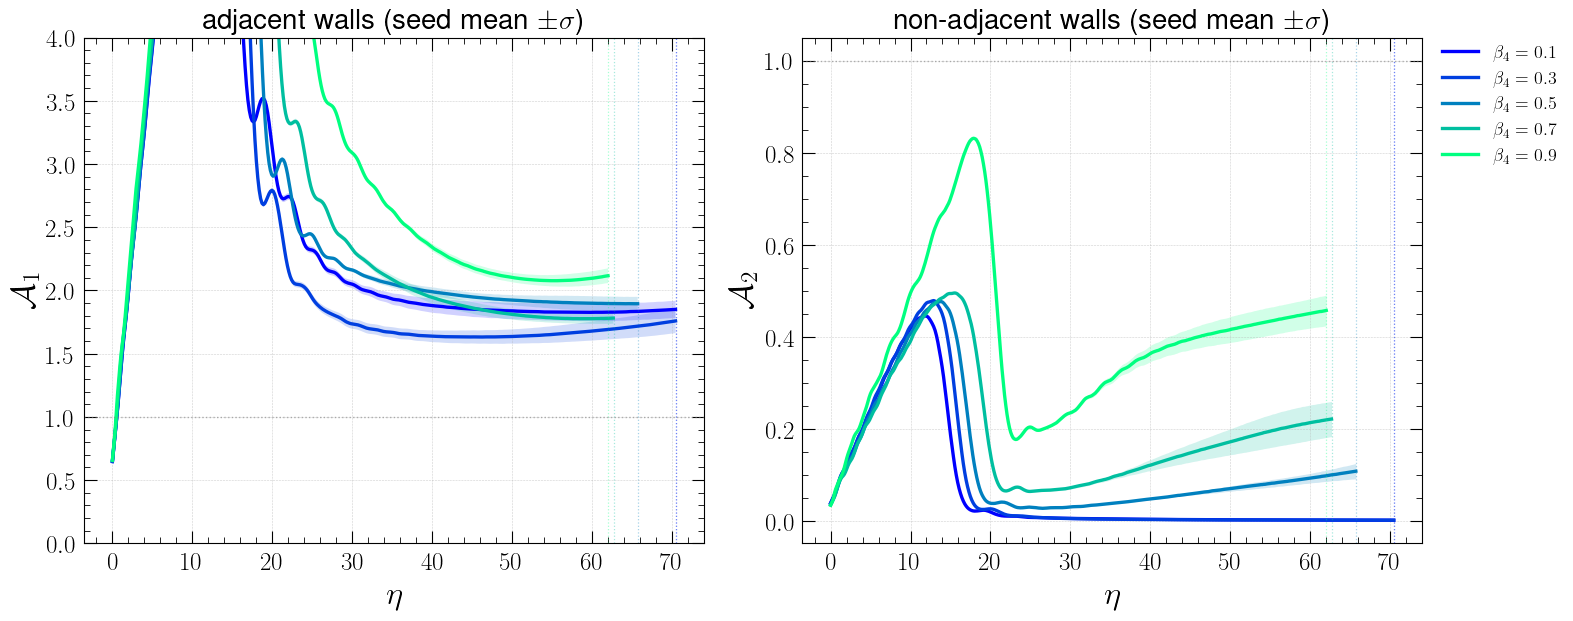

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, lambda r: area_param('scal1', r))
    if eta.size:
        axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eta, np.clip(mean - std, 1e-30, None), mean + std,
                             color=COLOR[b], alpha=0.18, lw=0)
        horizon_guide_end(axes[0], b)
    eta2, mean2, std2, n2 = seed_mean_std(b, lambda r: area_param('scal2', r))
    if eta2.size:
        axes[1].plot(eta2, mean2, color=COLOR[b], lw=2.4)
        axes[1].fill_between(eta2, np.clip(mean2 - std2, 1e-30, None), mean2 + std2,
                             color=COLOR[b], alpha=0.18, lw=0)
        horizon_guide_end(axes[1], b)

for ax in axes:
    # ax.set_xscale('log'); ax.set_yscale('log')
    ax.axhline(1.0, color='gray', ls=':', lw=1.0, alpha=0.6)
axes[0].set_ylim(0,4)
paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'adjacent walls (seed mean $\pm\sigma$)')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_2$', title=r'non-adjacent walls (seed mean $\pm\sigma$)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 7. Local logarithmic slope ${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$

Computed **per seed first** (only $\eta>1.5\,\eta_{\rm break}$ to skip the transient), then
aggregated across seeds. Scaling $\Leftrightarrow$ slope $\to0$ (horizontal guide).

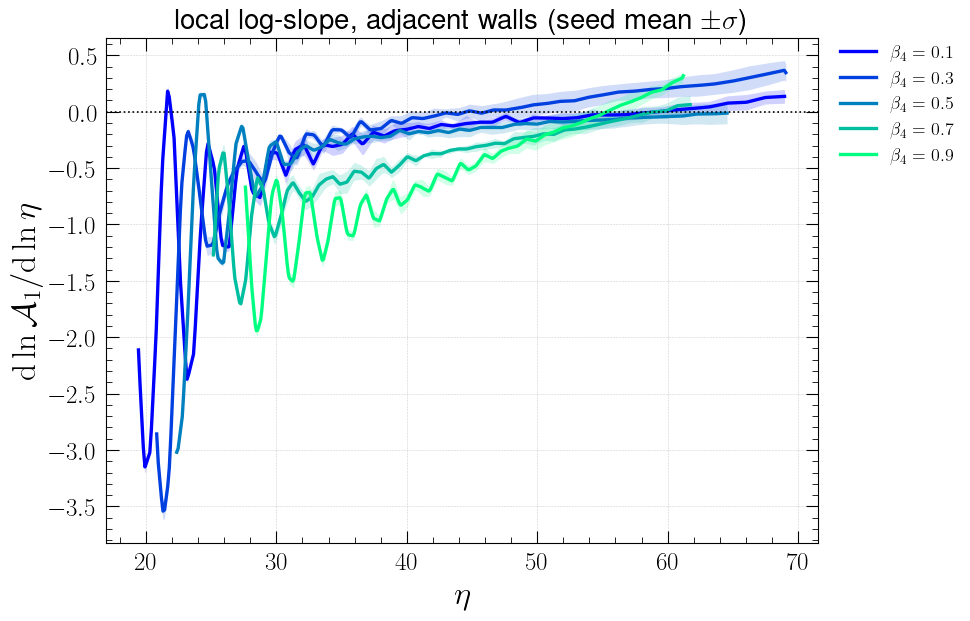

In [14]:
def logslope_curve(run, key='scal1'):
    eta, A = area_param(key, run)
    eb = breaking_onset_eta(run)
    sel = eta > (1.5 * eb if eb is not None else 0)
    return local_logslope(eta[sel], A[sel])


fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, lambda r: logslope_curve(r, 'scal1'))
    if eta.size == 0:
        continue
    ax.plot(eta, mean, color=COLOR[b], lw=2.4)
    ax.fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

ax.axhline(0, color='k', ls=':', lw=1.2)
# ax.set_xscale('log')
paper_ax(ax, ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$',
         title=r'local log-slope, adjacent walls (seed mean $\pm\sigma$)')
add_legend(ax, BETAS)
plt.tight_layout(); plt.show()

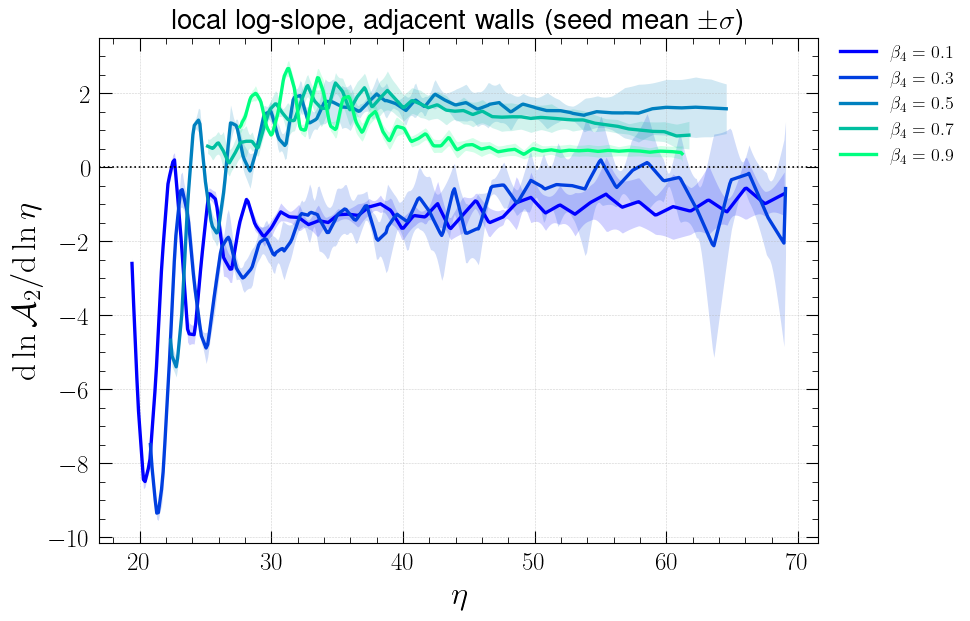

In [15]:
def logslope_curve(run, key='scal2'):
    eta, A = area_param(key, run)
    eb = breaking_onset_eta(run)
    sel = eta > (1.5 * eb if eb is not None else 0)
    return local_logslope(eta[sel], A[sel])


fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, lambda r: logslope_curve(r, 'scal2'))
    if eta.size == 0:
        continue
    ax.plot(eta, mean, color=COLOR[b], lw=2.4)
    ax.fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

ax.axhline(0, color='k', ls=':', lw=1.2)
# ax.set_xscale('log')
paper_ax(ax, ylabel=r'${\rm d}\ln\mathcal{A}_2/{\rm d}\ln\eta$',
         title=r'local log-slope, adjacent walls (seed mean $\pm\sigma$)')
add_legend(ax, BETAS)
plt.tight_layout(); plt.show()

## 8. In-window slope vs $\beta$ (equal-horizon / own-end) --- THE key result

Per seed, fit a line to $\ln\mathcal{A}_1$ vs $\ln\eta$ over
$\eta\in[1.5\,\eta_{\rm break},\,\eta_{\rm end}]$, where $\eta_{\rm end}$ is **that run's own
last $\eta$** (its 2-horizon end). Errorbar = across-seed mean $\pm1\sigma$. A slope
consistent with $0$ within error means scaling.

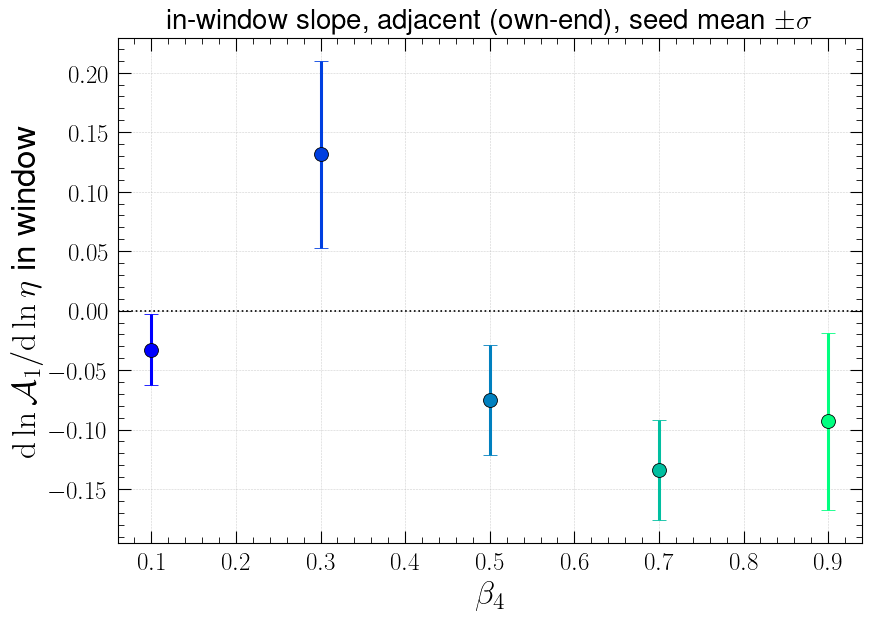

 beta4  n_seeds  slope_mean  slope_std
----------------------------------------
   0.1        5     -0.0327     0.0298
   0.3        5      0.1314     0.0788
   0.5        5     -0.0752     0.0464
   0.7        5     -0.1340     0.0424
   0.9        5     -0.0930     0.0742


In [16]:
def fit_logslope_window(run, key='scal1'):
    eta, A = area_param(key, run)
    eb = 30
    lo = 1.5 * eb if eb is not None else (eta[0] if eta.size else 0.0)
    # hi = own end (no cap) -> 2-horizon end; guard eta>0 (no log(0)) and finiteness
    hi = 65
    sel = (eta >= lo) & (eta <= hi) & (eta > 0) & (A > 0) & np.isfinite(A) & np.isfinite(eta) 
    x = np.log(eta[sel]); y = np.log(A[sel])
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 5 or np.ptp(x) <= 0:
        return np.nan
    return float(np.polyfit(x, y, 1)[0])   # slope of ln A vs ln eta


def slope_summary(key):
    sm, ss, sn = {}, {}, {}
    for b in BETAS:
        vals = np.array([fit_logslope_window(r, key) for r in RUNS.get(b, {}).values()])
        vals = vals[np.isfinite(vals)]
        sm[b] = np.nanmean(vals) if vals.size else np.nan
        ss[b] = np.nanstd(vals)  if vals.size else np.nan
        sn[b] = vals.size
    return sm, ss, sn


slope_mean, slope_std, slope_n = slope_summary('scal1')

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [slope_mean[b]], yerr=[slope_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
ax.axhline(0, color='k', ls=':', lw=1.2)
paper_ax(ax, xlabel=r'$\beta_4$',
         ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$ in window',
         title=r'in-window slope, adjacent (own-end), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'slope_mean':>11s} {'slope_std':>10s}")
print('-' * 40)
for b in BETAS:
    print(f"{b:>6.1f} {slope_n[b]:>8d} {slope_mean[b]:>11.4f} {slope_std[b]:>10.4f}")

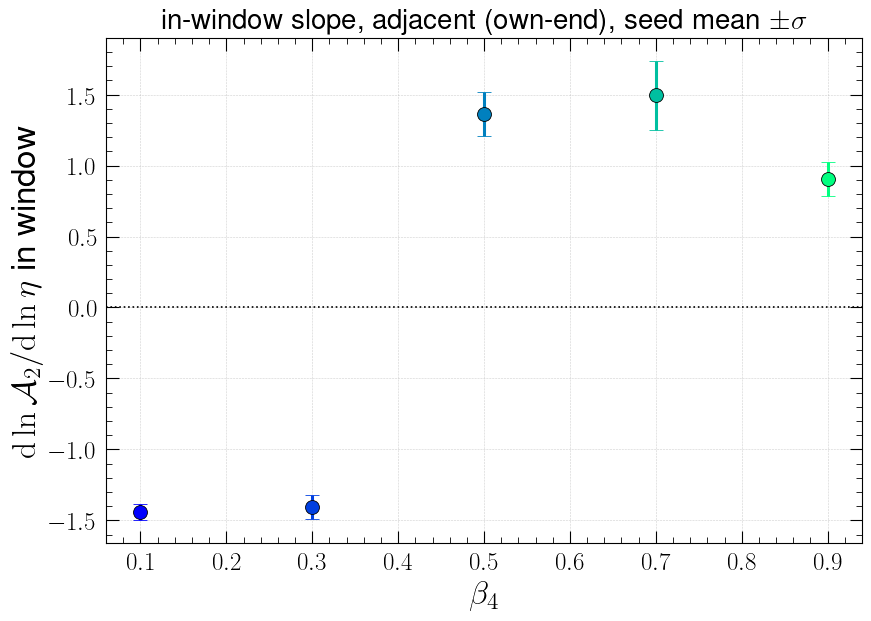

 beta4  n_seeds  slope_mean  slope_std
----------------------------------------
   0.1        5     -1.4428     0.0573
   0.3        5     -1.4075     0.0850
   0.5        5      1.3661     0.1554
   0.7        5      1.4951     0.2452
   0.9        5      0.9042     0.1203


In [17]:
def fit_logslope_window(run, key='scal2'):
    eta, A = area_param(key, run)
    eb = breaking_onset_eta(run)
    lo = 1.5 * eb if eb is not None else (eta[0] if eta.size else 0.0)
    # hi = own end (no cap) -> 2-horizon end; guard eta>0 (no log(0)) and finiteness
    sel = (eta >= lo) & (eta > 0) & (A > 0) & np.isfinite(A) & np.isfinite(eta)
    x = np.log(eta[sel]); y = np.log(A[sel])
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 5 or np.ptp(x) <= 0:
        return np.nan
    return float(np.polyfit(x, y, 1)[0])   # slope of ln A vs ln eta


def slope_summary(key):
    sm, ss, sn = {}, {}, {}
    for b in BETAS:
        vals = np.array([fit_logslope_window(r, key) for r in RUNS.get(b, {}).values()])
        vals = vals[np.isfinite(vals)]
        sm[b] = np.nanmean(vals) if vals.size else np.nan
        ss[b] = np.nanstd(vals)  if vals.size else np.nan
        sn[b] = vals.size
    return sm, ss, sn


slope_mean, slope_std, slope_n = slope_summary('scal2')

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [slope_mean[b]], yerr=[slope_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
ax.axhline(0, color='k', ls=':', lw=1.2)
paper_ax(ax, xlabel=r'$\beta_4$',
         ylabel=r'${\rm d}\ln\mathcal{A}_2/{\rm d}\ln\eta$ in window',
         title=r'in-window slope, adjacent (own-end), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'slope_mean':>11s} {'slope_std':>10s}")
print('-' * 40)
for b in BETAS:
    print(f"{b:>6.1f} {slope_n[b]:>8d} {slope_mean[b]:>11.4f} {slope_std[b]:>10.4f}")

## 9. $\mathcal{A}_1$ plateau value vs $\beta$ (own-end / 2-horizon)

Per seed, $\mathcal{A}_1$ averaged over the last $5\%$ of its own $\eta$-range (i.e. at its
2-horizon end), then across-seed mean $\pm1\sigma$ vs $\beta$. The $\eta$ at which each
$\beta$ is evaluated differs (printed below) but the **horizon coverage is matched**.

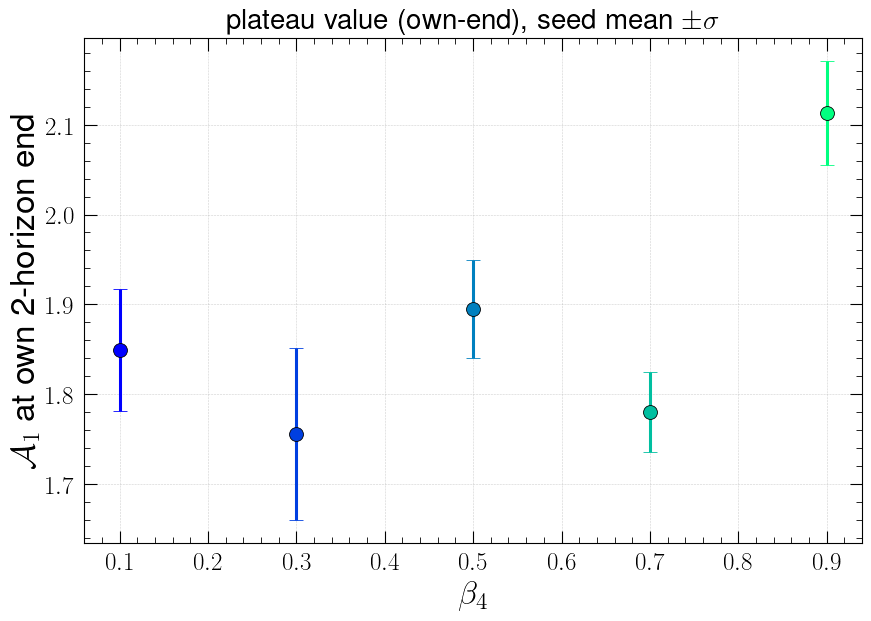

 beta4  n_seeds  eta_end   A1 mean   A1 std
--------------------------------------------
   0.1        5     70.5    1.8488   0.0678
   0.3        5     70.5    1.7553   0.0956
   0.5        5     65.7    1.8948   0.0544
   0.7        5     62.7    1.7807   0.0444
   0.9        5     62.0    2.1135   0.0578


In [18]:
def A_at_own_end(run, key='scal1', frac=0.99):
    eta, A = area_param(key, run)
    if eta.size < 2:
        return np.nan, np.nan
    sel = eta >= frac * eta[-1]
    if not sel.any():
        sel = np.array([eta.size - 1])
    return float(np.nanmean(A[sel])), float(eta[-1])

# ETA_FID = 61.0

# def A1_at_eta(run, eta_fid=ETA_FID):
#     eta, A = area_param('scal1', run)
#     if eta.size < 2 or eta_fid < eta[0] or eta_fid > eta[-1]:
#         return np.nan
#     return float(np.interp(eta_fid, eta, A)),float(eta[-1])


def plateau_summary(key):
    pm, ps, pn, pe = {}, {}, {}, {}
    for b in BETAS:
        vals, ends = [], []
        for r in RUNS.get(b, {}).values():
            v, e = A_at_own_end(r,key)
            if np.isfinite(v):
                vals.append(v); ends.append(e)
        vals = np.array(vals)
        pm[b] = np.nanmean(vals) if vals.size else np.nan
        ps[b] = np.nanstd(vals)  if vals.size else np.nan
        pn[b] = vals.size
        pe[b] = np.mean(ends) if ends else np.nan
    return pm, ps, pn, pe


plateau_mean, plateau_std, plateau_n, plateau_eta = plateau_summary('scal1')

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [plateau_mean[b]], yerr=[plateau_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
paper_ax(ax, xlabel=r'$\beta_4$', ylabel=r'$\mathcal{A}_1$ at own 2-horizon end',
         title=r'plateau value (own-end), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'eta_end':>8s} {'A1 mean':>9s} {'A1 std':>8s}")
print('-' * 44)
for b in BETAS:
    print(f"{b:>6.1f} {plateau_n[b]:>8d} {plateau_eta[b]:>8.1f}"
          f" {plateau_mean[b]:>9.4f} {plateau_std[b]:>8.4f}")

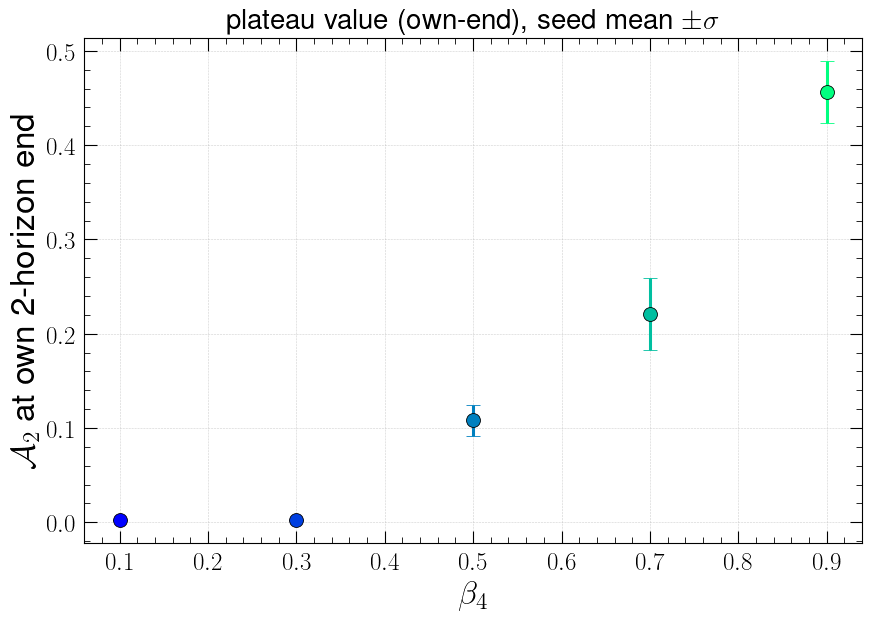

 beta4  n_seeds  eta_end   A1 mean   A1 std
--------------------------------------------
   0.1        5     70.5    0.0023   0.0002
   0.3        5     70.5    0.0024   0.0003
   0.5        5     65.7    0.1080   0.0161
   0.7        5     62.7    0.2211   0.0381
   0.9        5     62.0    0.4565   0.0332


In [27]:
def A_at_own_end(run, key='scal2', frac=0.99):
    eta, A = area_param(key, run)
    if eta.size < 2:
        return np.nan, np.nan
    sel = eta >= frac * eta[-1]
    if not sel.any():
        sel = np.array([eta.size - 1])
    return float(np.nanmean(A[sel])), float(eta[-1])

# ETA_FID = 61.0

# def A1_at_eta(run, eta_fid=ETA_FID):
#     eta, A = area_param('scal1', run)
#     if eta.size < 2 or eta_fid < eta[0] or eta_fid > eta[-1]:
#         return np.nan
#     return float(np.interp(eta_fid, eta, A)),float(eta[-1])


def plateau_summary(key):
    pm, ps, pn, pe = {}, {}, {}, {}
    for b in BETAS:
        vals, ends = [], []
        for r in RUNS.get(b, {}).values():
            v, e = A_at_own_end(r,key)
            if np.isfinite(v):
                vals.append(v); ends.append(e)
        vals = np.array(vals)
        pm[b] = np.nanmean(vals) if vals.size else np.nan
        ps[b] = np.nanstd(vals)  if vals.size else np.nan
        pn[b] = vals.size
        pe[b] = np.mean(ends) if ends else np.nan
    return pm, ps, pn, pe


plateau_mean, plateau_std, plateau_n, plateau_eta = plateau_summary('scal2')

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [plateau_mean[b]], yerr=[plateau_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
paper_ax(ax, xlabel=r'$\beta_4$', ylabel=r'$\mathcal{A}_2$ at own 2-horizon end',
         title=r'plateau value (own-end), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'beta4':>6s} {'n_seeds':>8s} {'eta_end':>8s} {'A1 mean':>9s} {'A1 std':>8s}")
print('-' * 44)
for b in BETAS:
    print(f"{b:>6.1f} {plateau_n[b]:>8d} {plateau_eta[b]:>8.1f}"
          f" {plateau_mean[b]:>9.4f} {plateau_std[b]:>8.4f}")

## 10. Opposite-wall $\mathcal{A}_2$ and the ratio $\mathcal{A}_2/\mathcal{A}_1$ (Z4 only)

$\bar\sigma_{\rm opp}=2\bar\sigma_{\rm adj}$ exactly at $\beta_4=1/3$: below this the
opposite ($\pi$-jump) walls split into two adjacent walls (decaying ratio); above it they
are bound (stable/rising ratio). Left: $\mathcal{A}_2$ seed mean $\pm1\sigma$; right: the
ratio across the $\beta_4=1/3$ transition. Faint verticals = each $\beta$'s 2-horizon end.

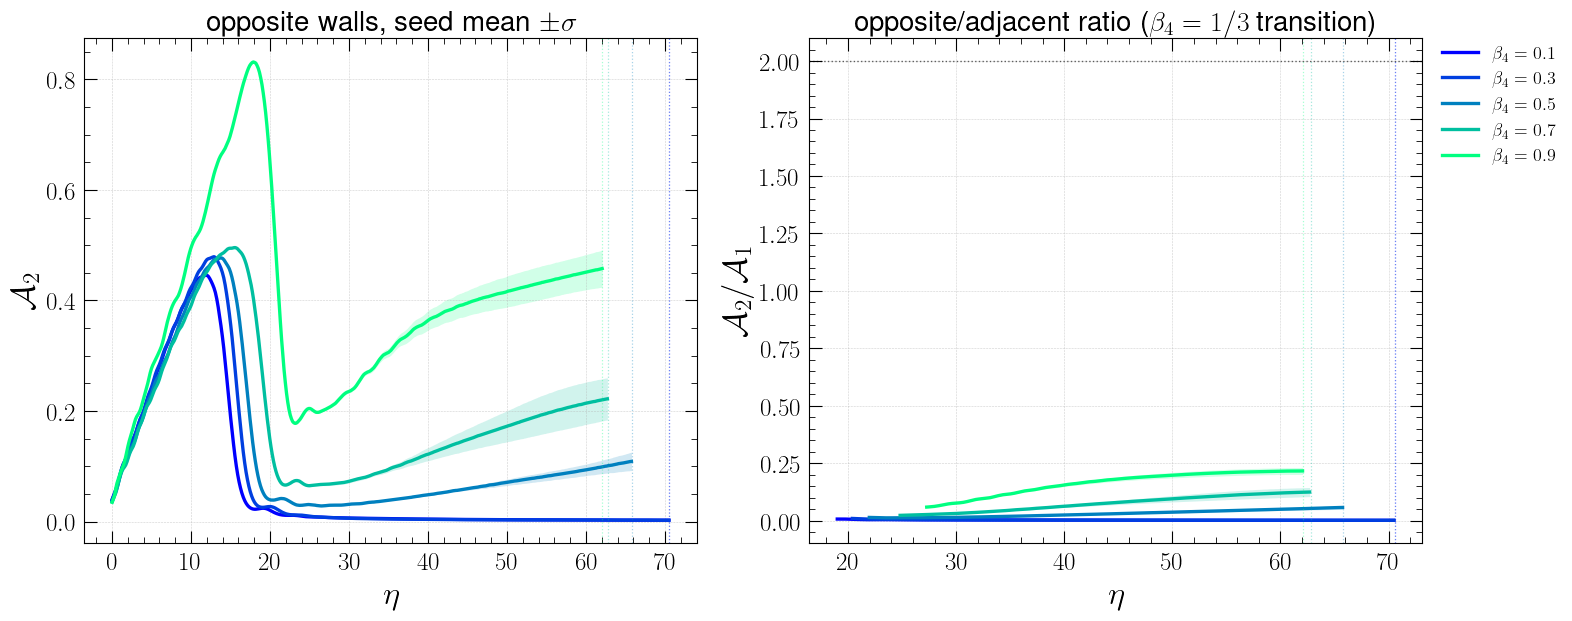

In [20]:
def ratio_curve(run):
    eta1, A1 = area_param('scal1', run)
    eta2, A2 = area_param('scal2', run)
    n = min(len(eta1), len(eta2))
    eta = eta1[:n]
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = A2[:n] / A1[:n]
    eb = breaking_onset_eta(run)
    sel = eta > (1.5 * eb if eb is not None else 0)
    return eta[sel], ratio[sel]


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, lambda r: area_param('scal2', r))
    if eta.size:
        axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)
        horizon_guide_end(axes[0], b)
    etar, meanr, stdr, nr = seed_mean_std(b, ratio_curve)
    if etar.size:
        axes[1].plot(etar, meanr, color=COLOR[b], lw=2.4)
        axes[1].fill_between(etar, meanr - stdr, meanr + stdr, color=COLOR[b], alpha=0.18, lw=0)
        horizon_guide_end(axes[1], b)

axes[1].axhline(2.0, color='k', ls=':', lw=1.0, alpha=0.6)
paper_ax(axes[0], ylabel=r'$\mathcal{A}_2$', title=r'opposite walls, seed mean $\pm\sigma$')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_2/\mathcal{A}_1$',
         title=r'opposite/adjacent ratio ($\beta_4=1/3$ transition)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 11. Summary table

Per $\beta$: seeds present, mean formation-onset $\eta$ (turnaround), mean $\langle|\Phi|^2\rangle$ at the
end (compare to the $\mu^2/2=0.00245$ vacuum), the $\mathcal{A}_1$ own-end plateau and
in-window slope (mean$\pm$std), and the mean $\mathcal{A}_2$ at the end.

In [21]:
def eb_per_seed(b):
    return [breaking_onset_eta(r) for r in RUNS.get(b, {}).values()]

def phi2_end_per_seed(b):
    vals = []
    for r in RUNS.get(b, {}).values():
        eta, p2 = phi2_radial(r)
        if p2.size:
            vals.append(p2[-1])
    return vals

def A2_end_per_seed(b):
    vals = []
    for r in RUNS.get(b, {}).values():
        eta, A2 = area_param('scal2', r)
        if A2.size:
            vals.append(A2[-1])
    return vals

print(f"{'beta4':>6s} {'n':>3s} {'eta_brk':>8s} {'<|Phi|2>_end':>13s} {'(vac=%.4f)'%VAC:>12s}"
      f" {'A1_end':>8s} {'A1_std':>8s} {'slope':>8s} {'slp_std':>8s} {'A2_end':>8s}")
print('-' * 100)
for b in BETAS:
    ebs = [e for e in eb_per_seed(b) if e is not None]
    eb_mean = np.mean(ebs) if ebs else np.nan
    p2s = phi2_end_per_seed(b)
    p2_mean = np.mean(p2s) if p2s else np.nan
    a2s = A2_end_per_seed(b)
    a2_mean = np.mean(a2s) if a2s else np.nan
    print(f"{b:>6.1f} {len(RUNS.get(b, {})):>3d} {eb_mean:>8.2f} {p2_mean:>13.5f} {'':>12s}"
          f" {plateau_mean[b]:>8.4f} {plateau_std[b]:>8.4f}"
          f" {slope_mean[b]:>8.4f} {slope_std[b]:>8.4f} {a2_mean:>8.4f}")

 beta4   n  eta_brk  <|Phi|2>_end (vac=0.0025)   A1_end   A1_std    slope  slp_std   A2_end
----------------------------------------------------------------------------------------------------
   0.1   5    12.64       0.00242                1.8488   0.0678  -1.4428   0.0573   0.0023
   0.3   5    13.62       0.00240                1.7553   0.0956  -1.4075   0.0850   0.0024
   0.5   5    14.64       0.00239                1.8948   0.0544   1.3661   0.1554   0.1088
   0.7   5    16.55       0.00237                1.7807   0.0444   1.4951   0.2452   0.2220
   0.9   5    18.16       0.00233                2.1135   0.0578   0.9042   0.1203   0.4577


## 12. Energy route --- effective tension and the junction/radiation budget

The wall-area columns $\mathrm{scal}_{1,2}$ are a **geometric** PRS wall-area density
(vacuum-sector crossings): they measure the codim-1 wall sheets but are blind to the
codim-2 junction lines ($|\Phi|\to0$ string cores) and to wall kinetic energy. We compare
this geometric area to an **energy-based** one built from the kinetic+gradient density
already in `average_energies.txt` --- **no re-run needed**.

Define $\rho_{\rm KG}\equiv E_k+E_g = E_{k,1}+E_{k,2}+E_{g,1}+E_{g,2}$ (physical: it
redshifts, carries no vacuum offset; verified $E_{\rm tot}=\rho_{\rm KG}+\sum E_V$). The headline:

**Effective tension (needs no $\sigma$ input):**
$$\sigma_{\rm eff}(\eta)=\frac{a^2\,\rho_{\rm KG}}{\mathrm{scal}_1}=\frac{\sigma_{\rm energy/area}}{C},$$
with $C$ the `scal` area-calibration. If $\sigma_{\rm eff}$ matched the static BVP
adjacent-wall tension $\sigma_{\rm adj}(\beta)$, the network would be bare static sheets.
It does **not**: $\sigma_{\rm eff}\approx2\,\sigma_{\rm adj}$ at small $\beta$, and it never
plateaus (it drifts down as radiation dilutes --- see the verdict panel below).

**The 2$\times$ is physical, not a measurement artifact.** Three null-tests (2026-06-24):

- *Not high-$k$ radiation.* The gradient power spectrum $k^2S(k)$ is the flat,
  scale-invariant ($S\propto k^{-2}$) domain-wall plateau whose high-$k$ edge marches up
  *with* $k_{\rm wall}$; $>90\%$ of gradient power sits **below** $k_{\rm wall}$ at every time
  and essentially none above $2k_{\rm wall}$. There is **no separable radiation tail** to cut.
- *Not a bulk-motion boost.* For a boosted wall $E_g=\gamma\sigma/2$ and $E_v=\sigma/2\gamma$,
  so the geometric mean $2a^2\sqrt{E_g E_v}/\mathrm{scal}$ cancels $\gamma$ --- still
  $\approx2\times$ (and $E_k/E_g\approx1\Rightarrow v^2\approx1$ is unphysical for translation,
  i.e. the KE is wobble/wave, not bulk drift).
- *Not `scal` calibration.* A numpy reimplementation of `ZNvacuumPhase` on **known-area**
  fields gives $C=1.00$ (flat wall, any width) and $C\approx1.2$--$1.27$ (sphere / oblique /
  wiggled --- the PRS orientation weight mildly **over**-counts curved area). $C\ge1$ means
  $\sigma_{\rm eff}$ is an *under*-estimate of the true energy/area, so correcting it pushes
  the network to $\approx2.4\,\sigma_{\rm adj}$ --- the **wrong direction** to explain the excess.

So $\sigma_{\rm eff}$ is the **dynamical effective tension**, and the excess
$\approx1\times\sigma_{\rm adj}$ is genuine **in-band** network energy = junction
(string-core) + wall curvature/bending + wall-scale Goldstone radiation + wobble KE
($E_k\approx E_g$ at all times, even pre-formation). This excess is exactly the
$\mathcal{A}_E-\mathcal{A}_{\rm area}$ gap plotted further down.

**Reference tensions (now real BVP, no longer placeholders):** opposite-wall
$\sigma_{\rm opp}=\tfrac{2\sqrt2}{3}\mu^3$ (exact, $\beta$-independent) and adjacent
$\sigma_{\rm adj}(\beta)/\mu^3=\{0.291,\,0.453,\,0.549,\,0.629\}$ for
$\beta_4=\{0.1,0.3,0.5,0.7\}$ (BVP, `wall_width_box_calculator`; $\sigma_{\rm adj}=\mu^3\,
\bar\sigma_{\rm adj}(1-\beta)$). So $\mathcal{A}_E$ and the gap now carry a meaningful
cross-$\beta$ normalization.

**What this data cannot do:** split the junction-log from the radiation *inside* the excess
--- they overlap in $k$. That needs the in-sim plaquette junction-*length* counter (recompile
+ rerun). $\beta_4=0.9$ is excluded throughout (its physical run crashed, NaN at $a\sim46$).

In [22]:
# --- Energy-route helpers (junction extraction; physical runs only) ---
# rho_KG = Ek1+Ek2+Eg1+Eg2 (complex-scalar kinetic+gradient; physical, redshifts, no vacuum).
# Verified: Etot = rho_KG + (Ev1+Ev2+Ev3) on the data.

BETAS_E = [b for b in BETAS if b != 0.9]          # 0.9 physical run crashed -> exclude

# Exact, beta-INDEPENDENT opposite-wall tension (program/mu^3 units).
SIGMA_OPP = (2.0 * math.sqrt(2.0) / 3.0) * MU**3

# sigma_adj = mu^3 * sigbar_adj(beta) * (1-beta).  BVP values (wall_width_box_calculator,
#   solved 2026-06-24); sigbar_adj = dimensionless BVP tension, (1-beta) = program->phys.
#   sigma_adj/mu^3 = {0.291, 0.453, 0.549, 0.629, 0.725} for beta {0.1,0.3,0.5,0.7,0.9}.
SIGBAR_ADJ = {0.1: 0.3234, 0.3: 0.6473, 0.5: 1.0977, 0.7: 2.0976, 0.9: 7.2482}
SIGMA_ADJ  = {b: MU**3 * SIGBAR_ADJ[b] * (1.0 - b) for b in BETAS}


def rho_KG(run):
    en = run['energies']
    return en['eta'], en['Ek_1'] + en['Ek_2'] + en['Eg_1'] + en['Eg_2']


def sigma_eff(run):
    # tension-free: sigma_eff(eta) = a^2 rho_KG / scal1  (raw mu^3 units). Flat => pure wall.
    en, sf = run['energies'], run['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    rho = en['Ek_1'] + en['Ek_2'] + en['Eg_1'] + en['Eg_2']
    with np.errstate(divide='ignore', invalid='ignore'):
        return en['eta'], a_arr**2 * rho / en['scal1']


def area_energy(run, beta):
    # A_E = a * rho_KG / (2 sigma_adj H).  Extra 'a' mandatory (scal carries aI; rho physical).
    en, sf = run['energies'], run['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    rho = en['Ek_1'] + en['Ek_2'] + en['Eg_1'] + en['Eg_2']
    with np.errstate(divide='ignore', invalid='ignore'):
        return en['eta'], a_arr * rho / (2.0 * SIGMA_ADJ[beta] * H_arr)


def area_gap(run, beta):
    # gap = A_E - A_area (same eta grid: both live on en['eta'])
    eta_E, A_E = area_energy(run, beta)
    _,     A_A = area_param('scal1', run)
    return eta_E, A_E - A_A

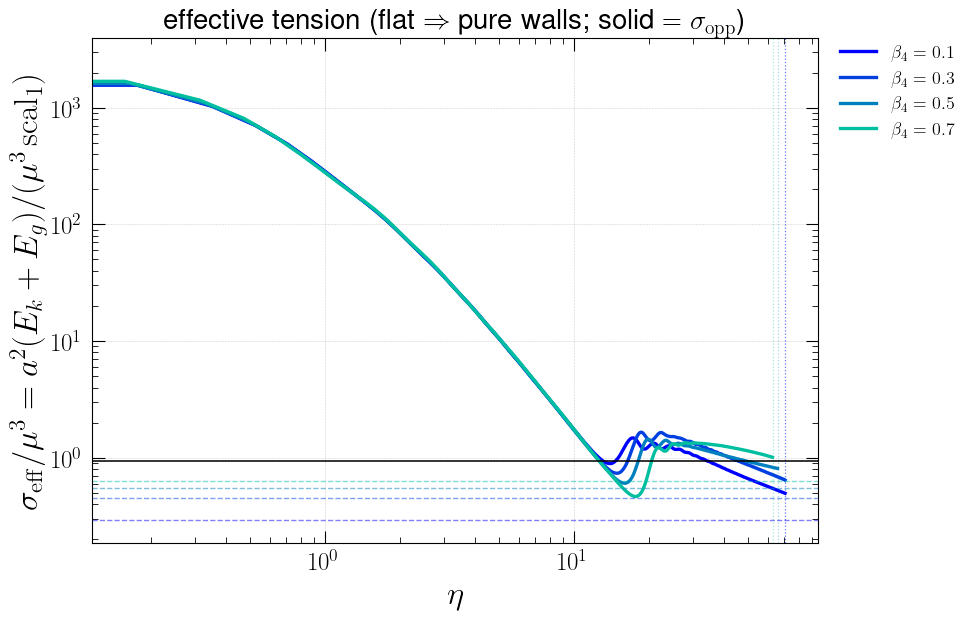

In [23]:
# Plot: effective tension sigma_eff/mu^3 = a^2(Ek+Eg)/(mu^3 scal1). Flat => pure walls.
# Black solid = exact opposite-wall sigma_opp/mu^3; dashed = adjacent sigma_adj (real BVP).
fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS_E:
    eta, mean, std, n = seed_mean_std(b, sigma_eff)
    if eta.size:
        ax.plot(eta, mean / MU**3, color=COLOR[b], lw=2.4)
        ax.fill_between(eta, np.clip((mean - std) / MU**3, 1e-30, None),
                        (mean + std) / MU**3, color=COLOR[b], alpha=0.18, lw=0)
        horizon_guide_end(ax, b)
ax.axhline(SIGMA_OPP / MU**3, color='k', ls='-', lw=1.4, alpha=0.8)
for b in BETAS_E:
    ax.axhline(SIGMA_ADJ[b] / MU**3, color=COLOR[b], ls='--', lw=1.0, alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
paper_ax(ax, ylabel=r'$\sigma_{\rm eff}/\mu^3=a^2(E_k+E_g)/(\mu^3\,{\rm scal}_1)$',
         title=r'effective tension (flat $\Rightarrow$ pure walls; solid $=\sigma_{\rm opp}$)')
add_legend(ax, BETAS_E)
plt.tight_layout(); plt.show()

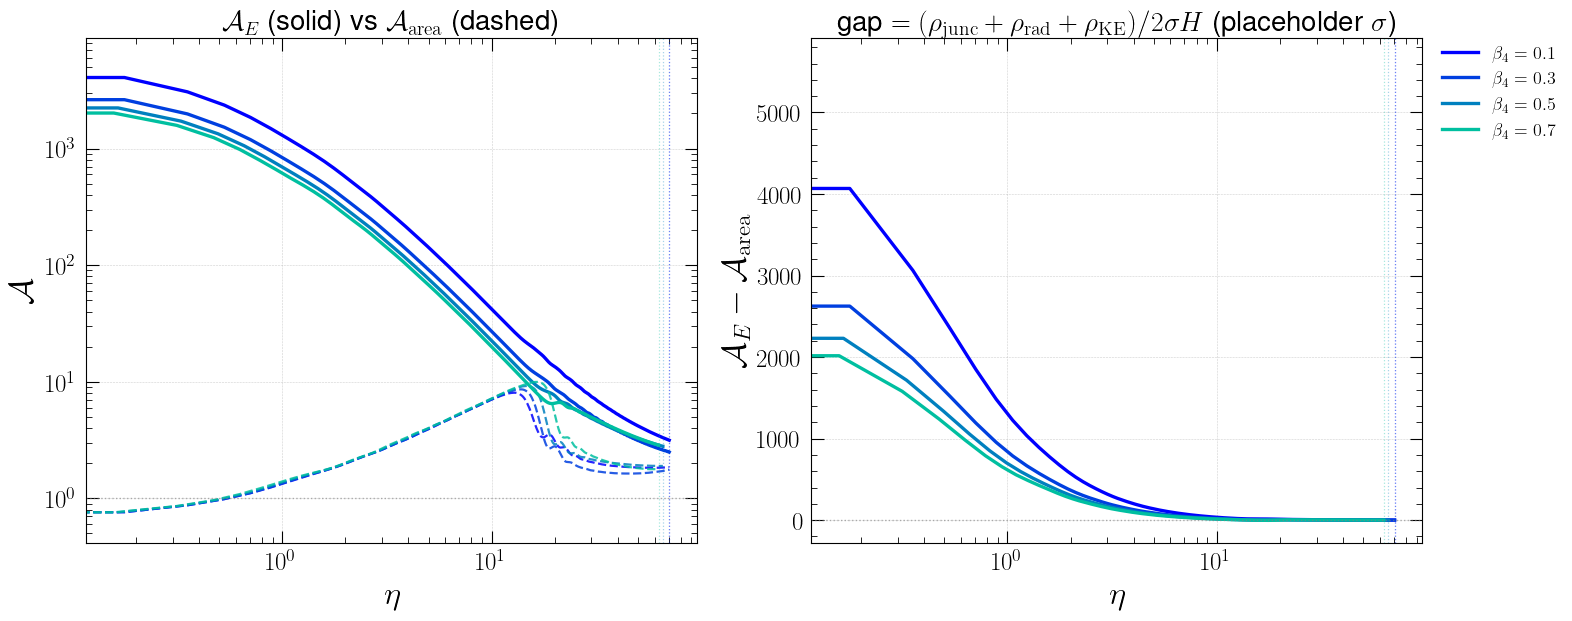

In [24]:
# Left: A_E (solid) vs geometric A_area (dashed). Right: gap = A_E - A_area.
# NOTE: A_E / gap scale as 1/sigma_adj (real BVP) -> cross-beta reading now meaningful.
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS_E:
    eE, mE, sE, _ = seed_mean_std(b, lambda r, b=b: area_energy(r, b))
    eA, mA, sA, _ = seed_mean_std(b, lambda r: area_param('scal1', r))
    if eE.size:
        axes[0].plot(eE, mE, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eE, np.clip(mE - sE, 1e-30, None), mE + sE,
                             color=COLOR[b], alpha=0.15, lw=0)
    if eA.size:
        axes[0].plot(eA, mA, color=COLOR[b], lw=1.6, ls='--', alpha=0.85)
    horizon_guide_end(axes[0], b)
    eg, mg, sg, _ = seed_mean_std(b, lambda r, b=b: area_gap(r, b))
    if eg.size:
        axes[1].plot(eg, mg, color=COLOR[b], lw=2.4)
        axes[1].fill_between(eg, mg - sg, mg + sg, color=COLOR[b], alpha=0.15, lw=0)
        horizon_guide_end(axes[1], b)

axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].axhline(1.0, color='gray', ls=':', lw=1.0, alpha=0.6)
axes[1].set_xscale('log')
axes[1].axhline(0.0, color='gray', ls=':', lw=1.0, alpha=0.6)
paper_ax(axes[0], ylabel=r'$\mathcal{A}$',
         title=r'$\mathcal{A}_E$ (solid) vs $\mathcal{A}_{\rm area}$ (dashed)')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_E-\mathcal{A}_{\rm area}$',
         title=r'gap $=(\rho_{\rm junc}+\rho_{\rm rad}+\rho_{\rm KE})/2\sigma H$ (placeholder $\sigma$)')
add_legend(axes[1], BETAS_E)
plt.tight_layout(); plt.show()

### $\sigma_{\rm eff}$ vs BVP $\sigma_{\rm adj}$ --- the verdict figure

$\sigma_{\rm eff}/\mu^3$ (seed mean $\pm\sigma$ band) against the **real BVP**
$\sigma_{\rm adj}$ (dotted, per $\beta$) and the exact $\sigma_{\rm opp}=\tfrac{2\sqrt2}{3}\mu^3$
(solid black). Shading marks each $\beta$'s **under-resolved** region ($<3$ cells/wall, with
$a=1+\eta$). The key reading: $\sigma_{\rm eff}$ sits $\sim2\times$ above $\sigma_{\rm adj}$
and never flattens, and the radiation-clean approach to the wall virial ($E_v\to E_g$) only
arrives *inside* the shaded zone --- resolved $\Rightarrow$ radiation-contaminated,
radiation-clean $\Rightarrow$ under-resolved. The network is not a set of bare static
adjacent sheets; the gap to $\sigma_{\rm adj}$ is the junction + radiation + KE budget (see
$\S12$ text and the $\mathcal{A}_E-\mathcal{A}_{\rm area}$ panel above).

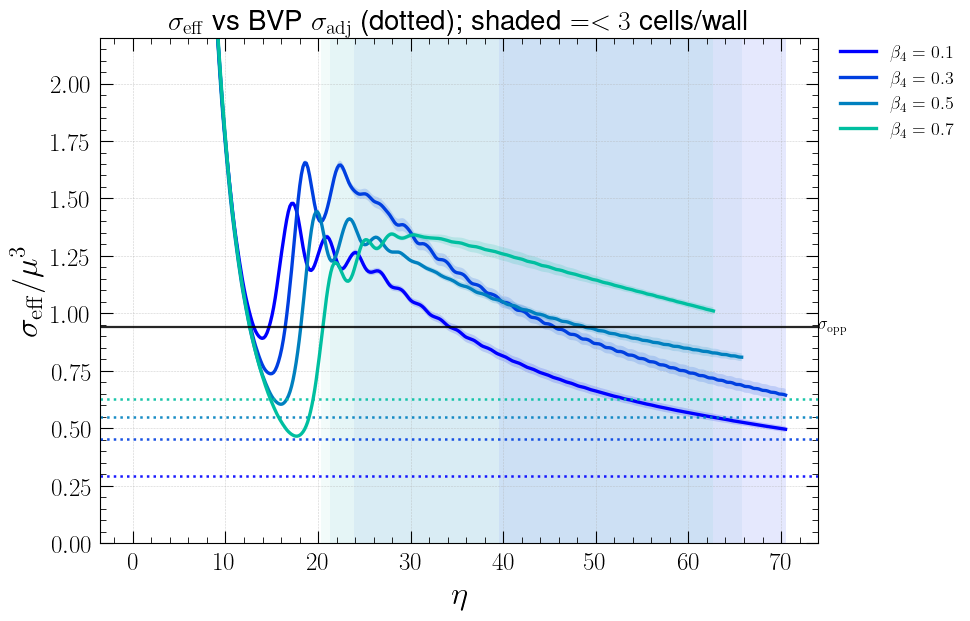

In [25]:
# sigma_eff/mu^3 vs eta with REAL BVP sigma_adj lines + under-resolution shading.
# Reuses globals defined earlier: BETAS_E, COLOR, MU, SIGMA_ADJ, SIGMA_OPP,
#   seed_mean_std, sigma_eff, paper_ax, add_legend, D_ADJ, DX.  (a = 1 + eta; H0/mu = 1.)
fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS_E:
    eta, mean, std, n = seed_mean_std(b, sigma_eff)
    if not eta.size:
        continue
    ax.plot(eta, mean / MU**3, color=COLOR[b], lw=2.4)
    ax.fill_between(eta, np.clip((mean - std) / MU**3, 0.0, None),
                    (mean + std) / MU**3, color=COLOR[b], alpha=0.16, lw=0)
    # real BVP adjacent-wall tension for this beta (dotted, same colour)
    ax.axhline(SIGMA_ADJ[b] / MU**3, color=COLOR[b], ls=':', lw=1.8, alpha=0.9)
    # under-resolved region: cells/wall = D_ADJ/(mu*a*dx) < 3  ->  a > D_ADJ/(3 mu dx)
    eta_res = D_ADJ[b] / (MU * 3.0 * DX[b]) - 1.0
    if eta_res < eta[-1]:
        ax.axvspan(max(eta_res, eta[0]), eta[-1], color=COLOR[b], alpha=0.05, lw=0)

ax.axhline(SIGMA_OPP / MU**3, color='k', ls='-', lw=1.6, alpha=0.85)
ax.text(ax.get_xlim()[1], SIGMA_OPP / MU**3, r'  $\sigma_{\rm opp}$',
        color='k', va='center', fontsize=12)
ax.set_ylim(0.0, 2.2)
paper_ax(ax, ylabel=r'$\sigma_{\rm eff}/\mu^3$',
         title=r'$\sigma_{\rm eff}$ vs BVP $\sigma_{\rm adj}$ (dotted); shaded $=<3$ cells/wall')
add_legend(ax, BETAS_E)
plt.tight_layout(); plt.show()

## 12. Resolution diagnostic: near-Nyquist gradient power $f_{\rm Ny}$

The box sizer guarantees the thinnest wall spans $\geq 1$ cell at the 2-horizon end, but
**"$\geq 1$ cell" is the Nyquist floor, not "resolved"**: a domain wall needs several cells
across its width before its gradient is faithfully represented on the lattice. Worse, in the
**physical** EOM the wall does not stay a fixed number of cells. The physical wall width
$w_{\rm phys}=\sqrt2\,\bar\delta/\mu$ is frozen in physical length, but the comoving grid
expands with $a$, so the **comoving** wall width $w_{\rm com}=w_{\rm phys}/a$ shrinks
$\propto 1/a$. The cells across a wall,
$n_{\rm cell}=w_{\rm com}/{\rm d}x=\bar\delta/(\mu\,a\,{\rm d}x)$, therefore **degrades
monotonically** as the universe expands --- every physical run drifts toward the grid scale;
the only question is when.

### The right metric: where the gradient energy lives in $k$

The cleanest, assumption-free way to ask "is the wall still resolved?" is to look at where the
field's gradient energy sits in Fourier space. The gradient energy density is
$$E_G=\tfrac12\langle|\nabla\Phi|^2\rangle=\tfrac12\sum_{\bf k} k^2\,|\Phi_{\bf k}|^2,$$
so the **gradient-power spectrum** is $P_{\rm grad}(k)=k^2\,S(k)$ --- the lattice field power
spectrum $S(k)=|\Phi_k|^2$ (column 2 of `spectra_scalar_i.txt`) weighted by $k^2$. We sum both
real components, $S(k)=S_0(k)+S_1(k)$, to match $E_G=E_{G_1}+E_{G_2}$.

A smooth, well-resolved wall of comoving width $w_{\rm com}$ concentrates its gradient power
around $k_{\rm wall}\simeq 2\pi/w_{\rm com}=2\pi\,\mu\,a/(\sqrt2\,\bar\delta)$ --- far below the
grid cutoff. As $a$ grows, $k_{\rm wall}$ marches **upward** toward the 1-D Nyquist wavenumber
$$k_{\rm Nyq}=\frac{\pi}{{\rm d}x}=\frac{\pi N}{L_\beta}.$$
When $k_{\rm wall}$ reaches the top of the band the wall is no longer a smooth object but a
grid-scale feature: gradient power piles up near $k_{\rm Nyq}$, and the measured `scal` (a
gradient-based area estimator) inflates --- exactly the spurious late-time rise of
$\mathcal{A}_1$ in $\S6$--$\S8$.

### Definition

We track the fraction of gradient power in the **top octave** of the band,
$$f_{\rm Ny}(t)=\frac{\sum_{k>k_{\rm cut}}k^2 S(k)}{\sum_{k}k^2 S(k)},
  \qquad k_{\rm cut}=\tfrac12\,k_{\rm Nyq}.$$
$f_{\rm Ny}\to0$ for a smooth, well-sampled wall; $f_{\rm Ny}\to\mathcal{O}(1)$ when the
structure is grid-scale. A snapshot is **resolved** while $f_{\rm Ny}\le f_{\rm thr}=0.1$ --- a
defensible convention: it is where the local slope ${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$
leaves the genuine-scaling band and begins climbing toward the artifact. $k_{\rm cut}$ and
$f_{\rm thr}$ are exposed as the one-line parameters `K_FRAC`, `F_THR`.

### What it shows (and why "larger $\beta$ scales better" is backwards here)

Pooling all available $\beta$ and seeds and binning by cells/wall, $f_{\rm Ny}$ rises
monotonically as the wall thins:

| cells/wall | $f_{\rm Ny}$ |
|---|---|
| 4--8 | 0.03 |
| 3--4 | 0.14 |
| 2--3 | 0.34 |
| 1.5--2 | 0.58 |

By $\sim1.5$ cells more than half the gradient energy is in the top octave. Crucially, at a
**fixed** cells/wall the larger-$\beta$ walls sit *higher* in $f_{\rm Ny}$ (at $a\approx31$:
$0.10,0.28,0.39,0.47,0.82$ for $\beta_4=0.1\!\to\!0.9$): their cores are stiffer (steeper
potential), so a nominal "2-cell" large-$\beta$ wall already carries substantial Nyquist
content. **The cells/wall count therefore understates the under-resolution of large $\beta$.**
This is the opposite of the PRS intuition (where $\mu\sim1$ freezes the wall width and large
$\beta$ looked closest to scaling): in the **physical** runs it is **small $\beta$** whose
$\mathcal{A}_1$ is trustworthy, and the large-$\beta$ flatness/upturn is sub-grid.

### Reading the panels

- **Left** --- $f_{\rm Ny}$ vs $\eta$ (seed mean $\pm\sigma$ on the sparse spectra grid). The
  dashed line is $f_{\rm thr}=0.1$; the table reports the $\eta$ at which each $\beta$ crosses
  it (the end of its resolved window).
- **Right** --- $f_{\rm Ny}$ vs cells/wall (adjacent), time running left$\to$right as walls
  thin: the universal degradation curve, with the large-$\beta$ points riding *above* the
  small-$\beta$ ones at the same cells/wall. The dotted vertical marks cells/wall $=3$
  ($f_{\rm Ny}\approx0.1$).
- **Table** --- per $\beta$: $(\eta,a,\text{cells/wall})$ at the $f_{\rm Ny}=0.1$ crossing vs at
  the 2-horizon end used by $\S8$/$\S9$, plus $f_{\rm Ny}$ **at** that 2-horizon end. The last
  column quantifies how far into the sub-grid regime the $\S8$/$\S9$ fit endpoint already is ---
  large for large $\beta$.

**Caveats.** Spectra are saved on a sparse grid (13--15 times/run), and only 2--3 of the 5
seeds are present so far, so the seed bands are indicative, not final. $f_{\rm thr}=0.1$ and
$k_{\rm cut}=k_{\rm Nyq}/2$ are conventions, not physics --- vary `K_FRAC`/`F_THR` to confirm
robustness. This cell is **purely diagnostic**: it does not alter the $\S8$/$\S9$ fits.

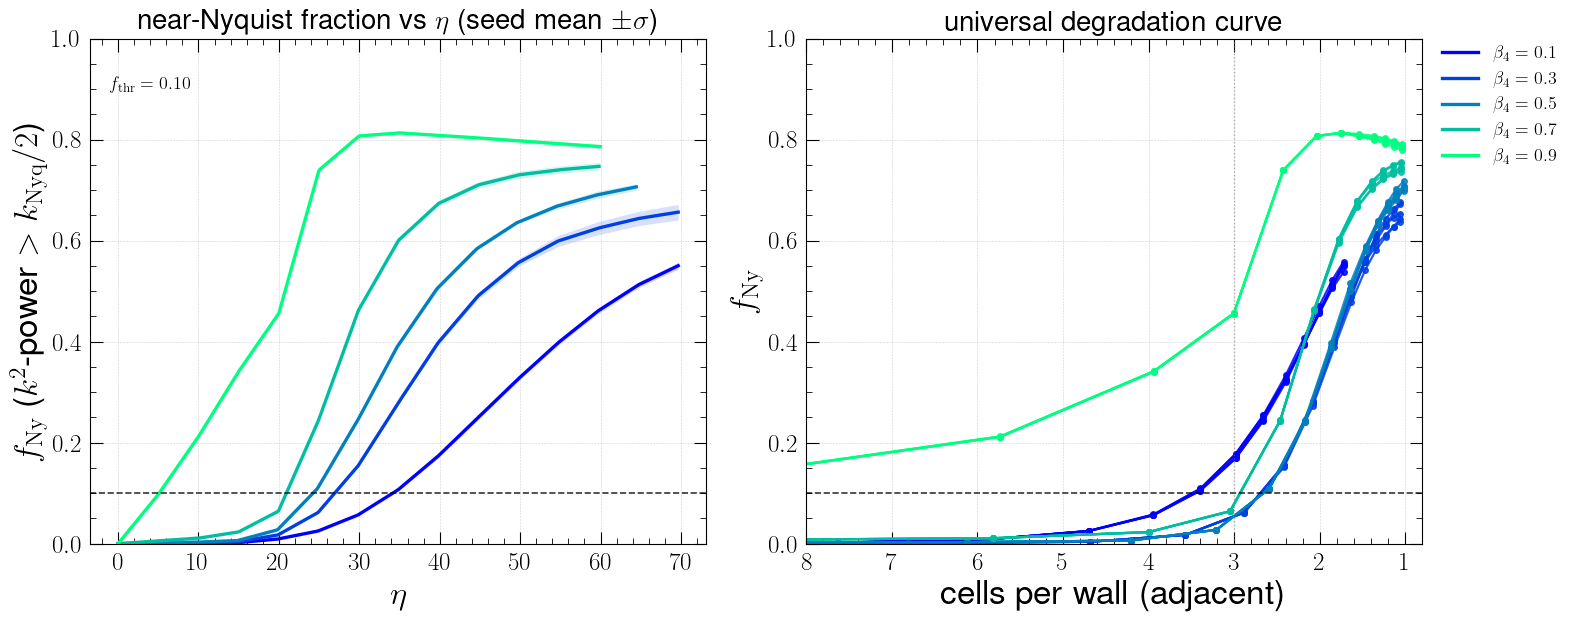

 beta4 |  eta_res   a_res  cw_res |  eta_2h    a_2h   cw_2h  fNy_2h
--------------------------------------------------------------------------
   0.1 |     34.2    35.2    3.45 |    70.6    71.6    1.70   0.550
   0.3 |     27.1    28.1    2.66 |    70.6    71.6    1.04   0.656
   0.5 |     24.4    25.4    2.63 |    65.8    66.8    1.00   0.706
   0.7 |     21.0    22.0    2.90 |    62.8    63.8    1.00   0.747
   0.9 |      5.3     6.3   10.07 |    62.1    63.1    1.00   0.786


In [26]:
# ============================================================================
# 12. Resolution diagnostic: near-Nyquist gradient power  f_Ny
#     f_Ny(t) = sum_{k>k_cut} k^2 S(k) / sum_k k^2 S(k),  k_cut = K_FRAC * k_Nyq
#     S(k) = S_0(k) + S_1(k) = |phi_k|^2 of both components (col 2 / index 1 of the
#            spectra files; index 2 is the field-DERIVATIVE / momentum spectrum).
#     "resolved" while f_Ny <= F_THR. Self-contained: reuses globals from earlier cells
#     (MU, N, L, DX, D_ADJ, BETAS, COLOR, run_dir, RUNS, TMAX, A_MAX, seed_mean_std,
#      paper_ax, add_legend, _safe_loadtxt).
# ============================================================================
K_FRAC = 0.5     # k_cut = K_FRAC * k_Nyq   (0.5 -> top octave)
F_THR  = 0.10    # snapshot is "resolved" while f_Ny <= F_THR


def _load_spec_field(path, idx):
    # spectra_scalar_<idx>.txt: nTimes blocks x nBins rows, cols [k, |phi_k|^2, |phi'_k|^2, n]
    sp = _safe_loadtxt(os.path.join(path, f'spectra_scalar_{idx}.txt'))
    tpath = os.path.join(path, 'average_spectra_times.txt')
    if sp is None or not os.path.exists(tpath):
        return None
    times = np.loadtxt(tpath).ravel()
    nt = times.size
    if nt < 1 or sp.shape[0] % nt != 0:
        return None
    nb = sp.shape[0] // nt
    blk = sp[:nt * nb].reshape(nt, nb, sp.shape[1])
    return times, blk[0, :, 0], blk[:, :, 1]      # times, k(nb), S(nt, nb)


def fNy_run(beta, seed):
    # -> (times, f_Ny, a, cells_per_wall_adj) or None
    path = run_dir(beta, seed)
    f0 = _load_spec_field(path, 0)
    if f0 is None:
        return None
    times, k, S = f0
    f1 = _load_spec_field(path, 1)
    if f1 is not None and f1[2].shape == S.shape:
        S = S + f1[2]
    kcut = K_FRAC * math.pi * N / L[beta]
    P = (k[None, :] ** 2) * S                        # (nt, nb)
    tot = P.sum(axis=1)
    hi = P[:, k > kcut].sum(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(tot > 0, hi / tot, np.nan)
    a = 1.0 + times
    cw = D_ADJ[beta] / (MU * a * DX[beta])
    return times, f, a, cw


def fNy_curve(run):
    # adapter for seed_mean_std: returns (eta, f_Ny)
    r = fNy_run(run['beta'], run['seed'])
    if r is None:
        return np.array([]), np.array([])
    return r[0], r[1]


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --- left: f_Ny vs eta (seed mean +/- sigma) ---
cross = {}     # beta -> eta where the seed-mean f_Ny crosses F_THR
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, fNy_curve)
    if eta.size == 0:
        continue
    axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
    axes[0].fill_between(eta, np.clip(mean - std, 0, None), mean + std,
                         color=COLOR[b], alpha=0.16, lw=0)
    over = np.where(mean > F_THR)[0]
    cross[b] = float(eta[over[0]]) if over.size else np.nan

axes[0].axhline(F_THR, color='k', ls='--', lw=1.2, alpha=0.8)
axes[0].text(0.03, 0.90, r'$f_{\rm thr}=%.2f$' % F_THR, transform=axes[0].transAxes,
             fontsize=13)
axes[0].set_ylim(0, 1)
paper_ax(axes[0], ylabel=r'$f_{\rm Ny}$  ($k^2$-power $>k_{\rm Nyq}/2$)',
         title=r'near-Nyquist fraction vs $\eta$ (seed mean $\pm\sigma$)')

# --- right: f_Ny vs cells/wall (all seeds, colored by beta); time -> left to right ---
for b in BETAS:
    for s in RUNS.get(b, {}):
        r = fNy_run(b, s)
        if r is None:
            continue
        _, f, _, cw = r
        m = np.isfinite(f)
        axes[1].plot(cw[m], f[m], color=COLOR[b], lw=1.6, marker='o', ms=4, alpha=0.85)
axes[1].axhline(F_THR, color='k', ls='--', lw=1.2, alpha=0.8)
axes[1].axvline(3.0, color='gray', ls=':', lw=1.0, alpha=0.6)
axes[1].set_xlim(8.0, 0.8)      # cells/wall decreasing -> time forward
axes[1].set_ylim(0, 1)
paper_ax(axes[1], xlabel=r'cells per wall (adjacent)',
         ylabel=r'$f_{\rm Ny}$', title=r'universal degradation curve')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

# --- table: resolved-window end vs 2-horizon end ---
print(f"{'beta4':>6s} | {'eta_res':>8s} {'a_res':>7s} {'cw_res':>7s} | "
      f"{'eta_2h':>7s} {'a_2h':>7s} {'cw_2h':>7s} {'fNy_2h':>7s}")
print('-' * 74)
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, fNy_curve)
    if eta.size == 0:
        continue
    er = cross.get(b, np.nan)
    a_r = 1.0 + er if np.isfinite(er) else np.nan
    cw_r = D_ADJ[b] / (MU * a_r * DX[b]) if np.isfinite(a_r) else np.nan
    fNy_2h = float(np.interp(TMAX[b], eta, mean))
    cw_2h = D_ADJ[b] / (MU * A_MAX[b] * DX[b])
    print(f"{b:>6.1f} | {er:>8.1f} {a_r:>7.1f} {cw_r:>7.2f} | "
          f"{TMAX[b]:>7.1f} {A_MAX[b]:>7.1f} {cw_2h:>7.2f} {fNy_2h:>7.3f}")